# 결측치에도 이유가 있다

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 🧹 결측치에도 이유가 있다 — 인덱싱·필터링·결측·이상치 처리

### — 더럽혀진 데이터를 *왜* 그렇게 고쳤는지 기록하는 법 —

---

## 📋 학습 목표

이 자습서를 마치면 여러분은 다음을 할 수 있습니다.

1. `.loc`·`.iloc`·불리언 인덱싱의 차이를 알고 상황에 맞게 골라 쓸 수 있습니다.
2. 다중 조건 불리언 필터링과 `isin`·`between`·`query`로 원하는 행을 정확히 골라낼 수 있습니다.
3. 결측치의 세 가지 유형(MCAR·MAR·MNAR)을 구분하고, 그 차이가 처리 전략을 어떻게 바꾸는지 설명할 수 있습니다.
4. 결측 패턴을 진단해 제거·평균/중앙값/최빈값 대체·그룹별 대체·전·후 채움 중 합리적인 방법을 고를 수 있습니다.
5. IQR 방법으로 이상치를 탐지하고, 비즈니스 맥락에 따라 제거·대체·유지를 판단할 수 있습니다.
6. 모든 결정에 대해 **"왜 이 방법을 골랐는가"** 를 한 줄씩 기록하는 습관을 만들 수 있습니다.

> 💡 위 목록을 천천히 읽고, 지금 내가 자신 있는 것과 아직 낯선 것을 마음속으로 표시해보세요. 오늘은 도구를 늘리는 날이 아니라, **판단하는 힘**을 늘리는 날입니다.

## 📚 목차

| Part | 내용 | 핵심 질문 |
| --- | --- | --- |
| Part 0 | 분석 상황과 학습 지도 | 어제 *발견*한 오염을, 이제 어떻게 *고치는가*? |
| Part 1 | 인덱싱 3종 — `.loc` · `.iloc` · 불리언 | 원하는 행과 열을 정확히 가리키는 법은? |
| Part 2 | 불리언 필터링 심화 | 복잡한 조건을 어떻게 깔끔하게 표현할까? |
| Part 3 | 결측 패턴 진단 | "어디가" 비었는지, "어떻게" 비어 있는지? |
| Part 4 | 결측 유형 — MCAR · MAR · MNAR | "왜" 비었는가? 유형에 따라 무엇이 달라지나? |
| Part 5 | 결측 처리 전략 의사결정 | 제거할까, 대체할까 — 무엇을 근거로 정할까? |
| Part 6 | IQR 이상치 탐지 | 어디까지가 "정상", 어디부터가 "튀는 값"인가? |
| Part 7 | 이상치 처리 의사결정 | 제거·대체·유지 — 비즈니스가 답을 정한다 |
| 종합 실습 | 오염된 단일 테이블 정제 + 판단 근거 기록 | 같은 데이터라도 *왜* 그렇게 고쳤는지 설명할 수 있는가? |
| 정리 | 핵심 요약 · 다음 시간 | 한 테이블을 고쳤다면, 그 다음에는? |

## 분석 상황과 학습 지도

# 0. 분석 상황과 학습 지도

## 지난 시간에는 무엇을 했나요?

어제(D+002) 우리는 **데이터에게 처음 말을 거는 법**을 배웠습니다. 자료형·컬렉션·함수에서 출발해 NumPy와 pandas를 만나고, `shape`·`info`·`describe`로 모두마켓 데이터를 진단했습니다. 그 결과 다섯 가지 오염을 *발견*했죠.

| 어제 발견한 오염 | 어디서 |
| --- | --- |
| 결측치(missing value) | `orders.amount`, `customers.gender` |
| 이상치(outlier) | `customers.age`(999, 음수), `orders.quantity`(100) |
| 표기 혼재 | `channel`(app/APP), `region`(서울/Seoul) |
| 날짜 포맷 혼재 | `orders.order_date` |
| 중복 행 | `orders` |

오늘은 이 중 **결측치와 이상치**를 본격적으로 다룹니다. 표기·날짜 혼재는 며칠 뒤 문자열·날짜 편에서, 여러 테이블 병합은 내일(D+004) 다룹니다.

## 오늘의 여정

```text
[Part 1] 인덱싱 3종         원하는 행·열을 정확히 가리키기
   ↓
[Part 2] 불리언 필터링 심화  복잡한 조건을 깔끔하게 표현
   ↓
[Part 3] 결측 패턴 진단      어디가, 어떻게 비었는가
   ↓
[Part 4] 결측 유형           왜 비었는가 — MCAR · MAR · MNAR
   ↓
[Part 5] 결측 처리 전략      제거 · 대체 — 무엇을 근거로?
   ↓
[Part 6] IQR 이상치 탐지     정상 범위의 경계 긋기
   ↓
[Part 7] 이상치 처리 의사결정 제거 · 대체 · 유지 — 비즈니스 맥락
   ↓
[종합 실습] 오염된 단일 테이블 정제 + 판단 근거 리포트
```

## 이 자습서 사용법

어제와 같습니다. 네 박자로 진행하세요.

- 📖 **읽고** — 개념 설명을 천천히 읽습니다.
- 💻 **실행하고** — 코드 셀을 위에서부터 순서대로 실행합니다. (`Shift + Enter`)
- ✏️ **고쳐보고** — "스스로 해보자!" 칸에서 코드를 직접 바꿔봅니다.
- 🤔 **답해보고** — 체크포인트 질문에 스스로 답해봅니다. 틀려도 괜찮습니다.

> ⚠ **오늘 자주 만날 새 단어:** 결측치(missing value), 이상치(outlier), 대체(imputation), 사분위수(quartile). 처음 듣더라도 본문에서 모두 설명하니 미리 외우지 마세요.

> 🎯 **오늘의 핵심**
> **"왜 이 방법을 골랐는가"를 한 줄로 적을 수 없다면, 그 처리는 하지 않은 것보다 위험합니다.** 코드보다 *근거*가 중요한 날입니다.

## 오늘의 무대: 모두마켓, 그 다음 날

여러분은 모두마켓에 입사한 **데이터 분석가**, 둘째 날입니다. 어제 진단으로 데이터에 결측·이상치가 있다는 사실은 알았지만 아직 손은 대지 않았습니다. 오늘 동료가 이렇게 말합니다.

> "어제 발견한 그 빈칸들, 그리고 999살 고객… 처리해주실 수 있을까요? 단, **어떻게 고쳤는지 보고서에 한 줄씩 적어달라고** 팀장님이 말씀하셨어요."

분석가의 일은 코드를 짜는 것에 끝나지 않습니다. **"왜 그렇게 처리했는지"** 를 동료가 1년 뒤에 읽어도 이해할 수 있게 남기는 것까지가 일입니다. 오늘 우리는 두 가지를 동시에 익힙니다 — *기법*과 *기록의 습관*.

아래 셀을 실행하면 오늘 쓸 모두마켓 데이터가 만들어집니다. 어제와 비슷하지만 오늘은 **결측·이상치를 살짝 더 다양하게** 심어 두었고, `customers`에 새 컬럼 `income`(연소득)을 추가했습니다 — Part 4·5에서 *그룹별 결측 대체*와 *MNAR 의심* 시나리오를 실습하기 위한 장치예요. 같은 모두마켓이지만 "오늘의 학습에 필요한 컬럼을 한 칸 더 가져왔다"고 생각하면 됩니다.

> **읽는 법:** 어제 본 데이터와 거의 같지만, 오늘은 `customers.income`(소득)이 추가됐고 결측이 더 다양하게 흩어져 있습니다. `orders.category`(상품 카테고리)도 미리 붙여두었는데, 이건 *결측·이상치 처리*에 집중하기 위해 병합 단계를 생략한 장치입니다(병합은 내일 D+004).

이제 데이터를 다루는 *손기술*부터 익힙니다. 결측·이상치를 처리하려면 먼저 **원하는 행과 열을 정확히 가리키는 법**부터 알아야 합니다.

In [1]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas matplotlib seaborn missingno -q

import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno   # 결측 패턴 시각화 전용 라이브러리 (Part 3에서 사용)

warnings.filterwarnings("ignore")

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (운영체제별 분기)
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3


In [2]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 (D+003 버전)
# - 어제 발견한 오염을 그대로 가져오되, 결측/이상치를 더 다양하게 심습니다.
# - 이 셀 하나로 오늘 쓸 데이터가 전부 준비됩니다 (이 노트북은 단독 실행 가능).
# ─────────────────────────────────────────────
np.random.seed(42)

# 1) 고객(customers)
n_customers = 300
customers = pd.DataFrame({
    "customer_id": [f"C{str(i).zfill(4)}" for i in range(1, n_customers + 1)],
    "age": np.random.normal(35, 9, n_customers).round().astype(int),
    "gender": np.random.choice(["M", "F"], n_customers),
    "region": np.random.choice(["서울", "경기", "부산", "인천", "대구"], n_customers),
    "membership": np.random.choice(["basic", "premium", "vip"], n_customers, p=[0.6, 0.3, 0.1]),
    "income": np.random.choice([2500, 3500, 4500, 6000, 8500], n_customers).astype(float),
})

# 오염 심기 — 나이 이상치
customers.loc[5, "age"] = 999            # 입력 실수로 보이는 이상치
customers.loc[10, "age"] = -3            # 음수 나이(불가능한 값)
customers.loc[15, "age"] = 120           # 매우 큰 값 (이상치 후보)

# 오염 심기 — 성별 결측 (관찰자가 응답을 안 받았을 가능성: MCAR에 가까움)
customers.loc[[20, 21, 22, 70, 120], "gender"] = np.nan

# 오염 심기 — 소득 결측 (고소득 고객일수록 응답 거절 → MNAR 신호)
high_income_mask = customers["income"] >= 6000
high_idx = customers[high_income_mask].sample(frac=0.4, random_state=1).index
customers.loc[high_idx, "income"] = np.nan

# 2) 상품(products)
categories = ["패션", "뷰티", "식품", "가전", "도서"]
n_products = 40
products = pd.DataFrame({
    "product_id": [f"P{str(i).zfill(3)}" for i in range(1, n_products + 1)],
    "category": np.random.choice(categories, n_products),
    "price": np.random.choice([9900, 19900, 29900, 49900, 89900, 129900], n_products),
})

# 3) 주문(orders)
n_orders = 2000
order_customer = np.random.choice(customers["customer_id"], n_orders)
order_product = np.random.choice(products["product_id"], n_orders)
price_map = products.set_index("product_id")["price"]
quantity = np.random.choice([1, 1, 1, 2, 2, 3], n_orders)
amount = price_map.loc[order_product].values * quantity

orders = pd.DataFrame({
    "order_id": [f"O{str(i).zfill(5)}" for i in range(1, n_orders + 1)],
    "customer_id": order_customer,
    "product_id": order_product,
    "category": products.set_index("product_id").loc[order_product, "category"].values,
    "quantity": quantity,
    "amount": amount.astype(float),
    "channel": np.random.choice(["web", "app"], n_orders, p=[0.5, 0.5]),
})

# 오염 심기 — 금액 결측 (일부 채널에서만 결측이 더 잦음 → MAR 신호)
app_mask = orders["channel"] == "app"
app_idx = orders[app_mask].sample(frac=0.04, random_state=2).index
web_idx = orders[~app_mask].sample(frac=0.01, random_state=3).index
orders.loc[app_idx.union(web_idx), "amount"] = np.nan

# 오염 심기 — 수량 이상치
orders.loc[7, "quantity"] = 100         # 비정상적으로 큰 주문 수량
orders.loc[1900, "quantity"] = 50       # 또 하나의 극단값
orders.loc[1500, "amount"] = 5_000_000  # 금액 자체의 극단값

print("모두마켓 데이터 생성 완료")
print("customers:", customers.shape, "| products:", products.shape, "| orders:", orders.shape)
print("\n[빠르게 둘러보기]")
print("customers 결측:", customers.isnull().sum().sum(), "건")
print("orders 결측:", orders.isnull().sum().sum(), "건")

모두마켓 데이터 생성 완료
customers: (300, 6) | products: (40, 3) | orders: (2000, 7)

[빠르게 둘러보기]
customers 결측: 51 건
orders 결측: 51 건


In [3]:
# 첫인상 — 어제 했던 진단을 한 번 더, 빠르게
print("=== customers ===")
display(customers.head())
print("\n=== orders ===")
display(orders.head())

=== customers ===


,customer_id,age,gender,region,membership,income
0,C0001,39,M,경기,premium,6000.0
1,C0002,34,F,부산,basic,4500.0
2,C0003,41,F,서울,premium,8500.0
3,C0004,49,M,대구,vip,3500.0
4,C0005,33,M,서울,basic,2500.0



=== orders ===


,order_id,customer_id,product_id,category,quantity,amount,channel
0,O00001,C0111,P004,도서,1,29900.0,app
1,O00002,C0014,P029,패션,3,149700.0,app
2,O00003,C0231,P009,식품,2,39800.0,app
3,O00004,C0084,P027,도서,1,29900.0,web
4,O00005,C0130,P026,식품,2,19800.0,app


## 인덱싱 3종 — `.loc` · `.iloc` · 불리언 인덱싱

# 1. 인덱싱 3종 — `.loc` · `.iloc` · 불리언 인덱싱

어제는 `df["amount"]`로 열을 꺼내고 `df[df["region"] == "서울"]`로 행을 골랐습니다. 그런데 결측을 *고치려면* "이 5번째 행의 이 열만 NaN으로 바꿔라", "이 조건을 만족하는 행의 이 열만 값을 채워라" 같은 **정밀한 가리키기**가 필요합니다. 도구가 더 필요합니다.

> ❓ **이 파트에서 답할 질문:** 원하는 **행과 열의 정확한 위치**를 어떻게 지목할까요? 그리고 같은 일을 가리키는 방법이 여럿일 때 무엇을 골라야 할까요?

## 💡 쉽게 말하면 — 세 가지 주소 체계

pandas에는 행·열을 가리키는 세 가지 방식이 있습니다. 우체국에 비유해봅시다.

```text
.loc      "라벨로 주소 부르기"     "강남구 역삼동 123-4 김민준"  ← 이름표(label)
.iloc     "위치 번호로 주소 부르기" "그 우편함의 5번째 칸"        ← 정수 위치(integer position)
불리언    "조건에 맞으면 다 호출"   "30대이고 서울 사는 사람 전원" ← True/False 줄
```

같은 행을 가리킬 수 있지만 **목적**이 다릅니다. `.loc`은 "내가 아는 이름으로", `.iloc`은 "위치 몇 번째로", 불리언은 "조건에 맞는 것 전부".

## 자세히 알아보기 — 비교표

| 방식 | 표기 | 가리키는 기준 | 슬라이스 끝 포함? | 주 용도 |
| --- | --- | --- | --- | --- |
| `.loc[행라벨, 열라벨]` | `df.loc[5, "age"]` | **라벨**(이름) | **포함**(`0:5` → 0,1,2,3,4,5) | 특정 행·열을 이름으로 정확히 |
| `.iloc[행번호, 열번호]` | `df.iloc[5, 1]` | **정수 위치** | **미포함**(`0:5` → 0,1,2,3,4) | 순서대로 N번째를 위치로 |
| 불리언 인덱싱 | `df[조건]` 또는 `df.loc[조건, "col"]` | **참/거짓 줄** | — | 조건에 맞는 행 전부 |

> ⚠ **자주 헷갈리는 함정 — 슬라이스 끝 포함 여부**
> `.loc[0:5]`는 **0부터 5까지 6개**, `.iloc[0:5]`는 **0부터 4까지 5개**입니다. 라벨 슬라이스는 끝을 *포함*하고, 위치 슬라이스는 *제외*합니다. NumPy 익숙한 분들이 자주 빠지는 함정이에요.

> 💡 **개념 연결:** 어제 본 `df[df["region"] == "서울"]`이 바로 불리언 인덱싱입니다. 오늘은 그것을 `.loc`과 결합해 **특정 행의 특정 열에만 값을 대입**하는 단계로 넘어갑니다. 결측 처리의 모든 코드가 이 패턴 위에 서 있습니다.

> **읽는 법:** `.loc[0:3]`은 0,1,2,3 네 행을 반환하지만 `.iloc[0:3]`은 0,1,2 세 행을 반환합니다. 이 차이는 결측 대체 코드를 "한 칸 차이로" 잘못 만들기 가장 쉬운 지점이에요. 라벨은 끝 포함, 위치는 끝 미포함 — 외워두면 평생 도움이 됩니다.

> **읽는 법:** `&`(그리고), `|`(또는)로 조건을 묶을 때는 **각 조건을 괄호로 감싸야 합니다**. 파이썬의 `and`/`or`가 아니라 `&`/`|`를 쓰는 점도 주의하세요. 이유는 pandas가 각 행마다 비교를 수행해야 하기 때문입니다.

## 데이터로 확인해 봅시다 — 결측 대체에 직접 쓰는 패턴

가장 자주 쓰는 두 가지 패턴을 미리 보여드립니다. Part 5에서 그대로 다시 등장합니다.

> **읽는 법:** 패턴 ②는 오늘 가장 자주 쓰는 한 줄입니다. "이상한 값을 일단 결측으로 표시해두고, 처리 방침은 따로 정한다"는 분석가의 표준 절차입니다. 무엇이 '이상한'지는 Part 6에서 IQR로 정량화합니다.

> 📌 **다른 산업에서는?** 이 인덱싱 패턴은 어디서나 같습니다. 금융은 "연체일 30일 이상인 행의 risk_grade를 'D'로", 헬스케어는 "혈압이 비현실적인 행의 측정값을 결측으로", 제조는 "센서값이 범위를 벗어난 행만 재측정 표시"에 똑같이 쓰입니다.

> 💡 **더 알고 싶다면 (선택):** 사실 `df["col"][조건] = 값` 같은 *체이닝* 형태도 동작하지만 `SettingWithCopyWarning`이 뜨고 가끔 적용이 안 됩니다. 안전을 위해 **할당은 항상 `.loc[조건, "col"] = 값` 한 줄에** 담는 습관을 들이세요.

### 스스로 해보자! ✏️ (1)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

1. **(따라하기)** `customers`의 **15번 라벨 행, age 열** 값을 출력하세요. `.loc`을 쓰세요.
2. **(응용)** `orders`에서 `category == "패션"`이고 `quantity >= 2`인 주문만 골라 앞 5행의 `order_id`, `amount`만 출력하세요.
3. **(생각해보기)** `.loc[0:5]`와 `.iloc[0:5]`는 각각 몇 개 행을 반환하나요? 왜 다를까요?

<details>
<summary>💡 힌트 (클릭)</summary>

```python
print(customers.loc[15, "age"])    # 의도적으로 심은 이상치 120이 보일 거예요

mask = (orders["category"] == "패션") & (orders["quantity"] >= 2)
display(orders.loc[mask, ["order_id", "amount"]].head())

# .loc[0:5] → 6개 (끝 포함), .iloc[0:5] → 5개 (끝 미포함)
# 라벨은 사람이 부르는 이름이라 자연스러운 '끝 포함'을, 위치는 파이썬 슬라이스 관례인 '끝 미포함'을 따릅니다.
```

</details>

### ✅ 짚고 넘어가기

1. `.loc`과 `.iloc`의 가장 큰 차이는 무엇인가요?
2. 불리언 조건에서 `&`/`|`를 쓸 때 주의할 점은 무엇인가요?
3. "조건 만족 행의 특정 열만 값을 바꾸려면" 어떤 패턴을 쓰나요?

> 💡 **다음 Part 예고:** 인덱싱의 기본 손기술은 익혔습니다. 그런데 실무 조건은 "30대이고 서울이며 (VIP 또는 프리미엄)" 처럼 길어집니다. 다음 Part에서는 이런 복잡한 조건을 깔끔하게 표현하는 도구들(`isin`·`between`·`query`)을 만납니다.

In [4]:
# 예제: .loc — 라벨(이름)로 가리키기
# customers의 인덱스는 0,1,2,... 정수이지만 '라벨'로 취급됩니다.

# 5번 라벨 행, 'age' 열 한 칸
print("customers.loc[5, 'age']  =", customers.loc[5, "age"])

# 0~3번 라벨 행, customer_id와 age 두 열만 (끝 포함!)
display(customers.loc[0:3, ["customer_id", "age"]])

customers.loc[5, 'age']  = 999


,customer_id,age
0,C0001,39
1,C0002,34
2,C0003,41
3,C0004,49


In [5]:
# 예제: .iloc — 정수 '위치'로 가리키기
# 0~3번 위치 행, 0~2번 위치 열 (끝 미포함!)
display(customers.iloc[0:3, 0:3])

# 마지막 두 행 (음수 위치 가능)
print("마지막 두 행:")
display(customers.iloc[-2:])

,customer_id,age,gender
0,C0001,39,M
1,C0002,34,F
2,C0003,41,F


마지막 두 행:


,customer_id,age,gender,region,membership,income
298,C0299,42,M,인천,premium,3500.0
299,C0300,41,F,인천,basic,4500.0


In [6]:
# 예제: 불리언 인덱싱 — 조건에 맞는 행 전부
# 조건(불리언 Series) 만들기
is_seoul = customers["region"] == "서울"
print("타입:", type(is_seoul).__name__, "/ True 개수:", is_seoul.sum())
print("앞 5개 미리보기:", is_seoul.head().tolist())

# 그 조건을 [ ]에 그대로 — 어제 본 패턴
seoul_customers = customers[is_seoul]
print("\n서울 고객 수:", len(seoul_customers))
display(seoul_customers.head(3))

타입: Series / True 개수: 62
앞 5개 미리보기: [False, False, True, False, True]

서울 고객 수: 62


,customer_id,age,gender,region,membership,income
2,C0003,41,F,서울,premium,8500.0
4,C0005,33,M,서울,basic,2500.0
5,C0006,999,F,서울,basic,NaN


In [7]:
# 예제: .loc + 불리언 — '조건 만족 행의 특정 열만' 가리키기 (오늘의 핵심 패턴)
# 30대 서울 고객의 멤버십만 꺼내기
mask = (customers["region"] == "서울") & (customers["age"].between(30, 39))
display(customers.loc[mask, ["customer_id", "age", "membership"]].head())

,customer_id,age,membership
4,C0005,33,basic
11,C0012,31,basic
21,C0022,33,basic
25,C0026,36,premium
41,C0042,37,basic


In [8]:
# 패턴 ①: 특정 조건 행의 한 열에 값 대입 — '서울'에 한해 region 값을 표준화
# 시연용 — 어제 표기 혼재로 본 ' 서울 '(앞뒤 공백)을 가상으로 만들었다가 정리
demo = customers.copy()
demo.loc[30, "region"] = " 서울 "
print("정리 전:", repr(demo.loc[30, "region"]))

# .loc로 그 한 칸을 지목해 값 대입
demo.loc[30, "region"] = demo.loc[30, "region"].strip()
print("정리 후:", repr(demo.loc[30, "region"]))

정리 전: ' 서울 '
정리 후: '서울'


In [9]:
# 패턴 ②: 조건 만족 행의 한 열을 한꺼번에 변경 — 이상치를 NaN으로 표시
demo2 = customers.copy()
print("처리 전 age 통계:")
print(demo2["age"].describe()[["min", "max"]])

# 0보다 작거나 120 이상이면 결측으로 표시(아직 처리 방침은 미정)
demo2.loc[(demo2["age"] < 0) | (demo2["age"] >= 120), "age"] = np.nan

print("\n처리 후 age 통계:")
print(demo2["age"].describe()[["min", "max"]])
print("결측이 된 개수:", demo2["age"].isnull().sum())

처리 전 age 통계:
min     -3.0
max    999.0
Name: age, dtype: float64

처리 후 age 통계:
min     6.0
max    70.0
Name: age, dtype: float64
결측이 된 개수: 3


In [10]:
# 스스로 해보자! (1)
# 1) 15번 라벨 행, age 열
# print(customers.loc[___, ___])

# 2) 패션 카테고리 + 수량 2 이상 주문의 order_id, amount 앞 5행
# mask = (orders["category"] == ___) & (orders["quantity"] >= ___)
# display(orders.loc[mask, [___, ___]].head())

## 불리언 필터링 심화 — 복잡한 조건을 깔끔하게

# 2. 불리언 필터링 심화 — 복잡한 조건을 깔끔하게

Part 1의 `mask = (cond1) & (cond2) & (cond3)`는 곧 길어지면 읽기 어려워집니다. 또 `region == "서울" or region == "부산" or region == "인천"`처럼 같은 열에 여러 후보를 비교하는 일도 잦죠. pandas는 이런 상황을 위한 **표현 도구**를 따로 갖고 있습니다.

> ❓ **이 파트에서 답할 질문:** 다중 조건과 "여러 값 중 하나" 같은 복잡한 필터를, 읽기 쉽고 실수 적게 쓰는 법은?

## 💡 쉽게 말하면 — 같은 의미, 더 짧은 문장

```text
[기본]   (df["region"] == "서울") | (df["region"] == "부산") | (df["region"] == "인천")
[깔끔]   df["region"].isin(["서울", "부산", "인천"])

[기본]   (df["age"] >= 30) & (df["age"] <= 39)
[깔끔]   df["age"].between(30, 39)

[기본]   df[(df["amount"] > 50000) & (df["channel"] == "web")]
[깔끔]   df.query("amount > 50000 and channel == 'web'")
```

같은 결과지만 후자는 의도가 한눈에 들어옵니다. 분석가의 시간은 *코드를 읽는 데* 가장 많이 쓰이므로, 짧고 명확한 표현이 곧 생산성입니다.

## 자세히 알아보기

| 도구 | 무엇을 하나 | 예시 |
| --- | --- | --- |
| `.isin([...])` | 여러 값 중 하나인지 검사 | `df["region"].isin(["서울","부산"])` |
| `.between(a, b)` | a 이상 b 이하인지 검사(기본 양끝 포함) | `df["age"].between(30, 39)` |
| `.query("...")` | 문자열 조건식으로 필터 | `df.query("age >= 30 and region == '서울'")` |
| `~` (틸드) | 불리언 반전 (NOT) | `df[~df["region"].isin(["서울"])]` |

> **읽는 법:** `~`는 "아닌 것"을 뜻합니다. 비싼 실수를 줄이려면, 차라리 "**서울인 사람을 제외한 사람들**"을 직접 표현하는 편이 안전합니다. 사람의 뇌는 부정문을 잘 놓치거든요.

## 결측을 포함한 필터링의 함정 — 오늘 가장 중요한 한 가지

`amount`가 비어 있는 행을 다룰 때 다음 결과를 보세요. 이 부분이 결측 처리의 *진짜 시작*입니다.

> **읽는 법:** `NaN > 0`도 `False`, `NaN <= 0`도 `False`입니다. 그래서 단순히 `df["amount"] > 0`로 필터하면 결측이 *조용히* 사라집니다. 분석가가 가장 자주 만드는 버그가 바로 이 지점에서 나옵니다.

해결책은 두 가지입니다.

> 💡 **개념 연결:** "결측은 조용히 사라진다"는 사실은 Part 5의 결측 처리 전략 전체를 떠받칩니다. *지운 줄 모르고 분석하는 것*보다 *지우기로 정하고 지우는 것*이 항상 낫습니다.

## 데이터로 확인해 봅시다

- **세그먼트 분석**: "30대 + 서울 + VIP" 같은 세그먼트는 `query`로 한 줄에 정의해두면 보고서마다 재사용하기 쉽습니다.
- **결측 안전 필터**: 조건과 결측은 **항상 같이** 생각하세요. `notna()`/`isnull()`을 잊지 않는 습관이 결국 분석의 신뢰도를 만듭니다.

> 📌 **다른 산업에서는?** 의료에서는 "특정 진단 코드들 중 하나(`isin`)에 속하면서, 환자 나이가 어린이 범위(`between`)인 경우"를 묶어 분석합니다. 마케팅은 "캠페인 기간 안(`between`)에 노출됐고, 특정 디바이스 종류(`isin`)인 사용자"를 세그먼트로 잡습니다.

### 스스로 해보자! ✏️ (2)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

1. **(따라하기)** `orders`에서 `category`가 `"패션"` 또는 `"뷰티"`이고 `amount`가 결측이 *아닌* 주문 건수를 세보세요.
2. **(응용)** 같은 조건을 `query()`로도 써보세요. (힌트: `amount == amount`는 결측이 아닌 값만 통과시키는 트릭이지만, 더 명확한 방법은 `amount.notna()`입니다.)
3. **(생각해보기)** `amount < 0`인 행을 찾았을 때 결과에 결측 행이 안 보였다면, 그 데이터에 결측이 없다고 결론 내려도 될까요?

<details>
<summary>💡 힌트 (클릭)</summary>

```python
mask = orders["category"].isin(["패션", "뷰티"]) & orders["amount"].notna()
print("건수:", mask.sum())

print(orders.query("category in ['패션', '뷰티'] and amount.notna()").shape)
```

3번 답: **결론 내릴 수 없습니다.** NaN과의 비교는 항상 False라서, 단순 비교 필터에는 결측이 *조용히 빠집니다*. 결측 존재 여부는 `isnull().sum()`으로 따로 확인해야 합니다. 오늘의 핵심 경고예요.

</details>

### ✅ 짚고 넘어가기

1. `isin`과 `between`은 어떤 상황에서 가독성을 살려주나요?
2. `NaN > 0`의 결과는 무엇인가요? 이게 분석에 어떤 위험을 만드나요?
3. "결측을 명시적으로 포함/제외하는 두 가지 방법"을 한 줄씩 코드로 적을 수 있나요?

> 💡 **다음 Part 예고:** 이제 결측을 *조용히 무시하지 않을* 손기술이 생겼습니다. 다음 Part부터는 결측을 정면으로 마주합니다. 먼저 "어디가, 어떻게 비었는지" 패턴을 진단합니다.

In [11]:
# 예제: isin과 between — 같은 결과를 두 방식으로
metro = ["서울", "경기", "인천"]

# 방법 A) 기본 |로 연결
mask_a = (customers["region"] == "서울") | (customers["region"] == "경기") | (customers["region"] == "인천")
print("방법 A 결과 수:", mask_a.sum())

# 방법 B) isin
mask_b = customers["region"].isin(metro)
print("방법 B 결과 수:", mask_b.sum())

# 두 결과가 완전히 같은지 검증
print("두 마스크가 완전히 동일?:", (mask_a == mask_b).all())

방법 A 결과 수: 176
방법 B 결과 수: 176
두 마스크가 완전히 동일?: True


In [12]:
# 예제: query — 문자열로 표현하는 필터
# 30대이면서 서울에 사는 프리미엄/VIP 고객
result = customers.query("age.between(30, 39) and region == '서울' and membership in ['premium', 'vip']")
print("해당 고객 수:", len(result))
display(result.head(3))

해당 고객 수: 4


,customer_id,age,gender,region,membership,income
25,C0026,36,M,서울,premium,2500.0
88,C0089,30,F,서울,premium,NaN
137,C0138,32,F,서울,premium,NaN


In [13]:
# 예제: ~ (NOT) — '서울 외 지역'
not_seoul = customers[~customers["region"].isin(["서울"])]
print("서울 외 지역 고객 수:", len(not_seoul))
print("지역 분포:")
print(not_seoul["region"].value_counts())

서울 외 지역 고객 수: 238
지역 분포:
region
부산    64
경기    60
대구    60
인천    54
Name: count, dtype: int64


In [14]:
# NaN과 비교는 항상 False 입니다 — 직관과 다름
sample = orders[["order_id", "amount"]].head(10).copy()
sample.loc[2, "amount"] = np.nan
display(sample)

print("\n== amount > 0 인 행 ==")
display(sample[sample["amount"] > 0])     # NaN 행은 제외됨 (조건이 False로 평가)

print("\n== amount <= 0 인 행 ==")
display(sample[sample["amount"] <= 0])    # 역시 NaN은 제외됨

,order_id,amount
0,O00001,29900.0
1,O00002,149700.0
2,O00003,NaN
3,O00004,29900.0
4,O00005,19800.0
5,O00006,129900.0
6,O00007,39800.0
7,O00008,29900.0
8,O00009,89900.0
9,O00010,9900.0



== amount > 0 인 행 ==


,order_id,amount
0,O00001,29900.0
1,O00002,149700.0
3,O00004,29900.0
4,O00005,19800.0
5,O00006,129900.0
6,O00007,39800.0
7,O00008,29900.0
8,O00009,89900.0
9,O00010,9900.0



== amount <= 0 인 행 ==


,order_id,amount


In [15]:
# 해결책 1) 결측을 명시적으로 포함하기
mask_with_na = (sample["amount"] > 0) | (sample["amount"].isnull())
print("결측 포함 필터:")
display(sample[mask_with_na])

# 해결책 2) 결측을 명시적으로 제외하기
mask_no_na = (sample["amount"] > 0) & (sample["amount"].notna())
print("\n결측 명시적 제외:")
display(sample[mask_no_na])

결측 포함 필터:


,order_id,amount
0,O00001,29900.0
1,O00002,149700.0
2,O00003,NaN
3,O00004,29900.0
4,O00005,19800.0
5,O00006,129900.0
6,O00007,39800.0
7,O00008,29900.0
8,O00009,89900.0
9,O00010,9900.0



결측 명시적 제외:


,order_id,amount
0,O00001,29900.0
1,O00002,149700.0
3,O00004,29900.0
4,O00005,19800.0
5,O00006,129900.0
6,O00007,39800.0
7,O00008,29900.0
8,O00009,89900.0
9,O00010,9900.0


In [16]:
# 스스로 해보자! (2)
# 1) isin + notna 조합
# mask = orders["category"].isin([___, ___]) & orders["amount"].___()
# print("건수:", mask.sum())

# 2) query로 같은 조건
# print(orders.query("category in [___, ___] and amount.notna()").shape)

## 결측 패턴 진단 — 어디가, 어떻게 비었는가

# 3. 결측 패턴 진단 — 어디가, 어떻게 비었는가

어제 `isnull().sum()`으로 "몇 개 비었는지"는 봤습니다. 그런데 **결측을 어떻게 처리할지**를 정하려면 그것만으로는 부족합니다. *어느 열들이 함께 비는가*, *어떤 행이 유난히 많이 비는가*, *결측 비율은 얼마인가* — 이런 **패턴**을 봐야 합니다.

> ❓ **이 파트에서 답할 질문:** 비어 있는 자리들이 "어디에 어떻게" 분포해 있는지를, 표와 그림으로 어떻게 확인할까?

## 💡 쉽게 말하면 — 잉크가 번진 신문 지면

결측 패턴 진단은 신문 지면에 잉크가 번진 자국을 보는 것과 같습니다. 잉크가 *한 칸*에만 번졌는지, *한 줄 전체*가 번졌는지, *특정 면*에 몰려 있는지에 따라 대응이 달라지죠. 데이터도 똑같습니다.

```text
[패턴 A] 한 열에만 결측이 산발     →   그 열만 단독 처리 가능
[패턴 B] 두 열이 같은 행에서 결측   →   같은 원인 의심 (예: 한 폼이 통째로 누락)
[패턴 C] 특정 그룹(채널·시간)에 쏠림 →   원인은 데이터 수집 과정에 있음
```

## 자세히 알아보기 — 결측 진단 5종 세트

| 도구 | 무엇을 알려주나 |
| --- | --- |
| `df.isnull().sum()` | 열별 결측 개수 |
| `df.isnull().mean()` | 열별 결측 **비율** (0~1) |
| `df.isnull().sum(axis=1)` | **행별** 결측 개수 (어떤 행이 많이 비었나) |
| `df[df["col"].isnull()]` | 특정 열이 결측인 행들 |
| 결측 히트맵(matplotlib) | 결측의 분포를 그림으로 |

> 💡 **개념 연결:** `axis=1`은 어제 NumPy의 "더 알고 싶다면" 박스에서 잠깐 나온 그 개념입니다. **세로(0)**·**가로(1)** — 가로로 더하면 *행별* 결측 개수가 됩니다.

> **읽는 법:** 비율이 **5% 이하**면 처리 영향이 작아 비교적 자유롭게 다룰 수 있고, **30% 이상**이면 그 열의 쓸모를 의심해야 합니다. 절대 기준은 아니지만 첫 감을 잡는 가이드입니다.

> **읽는 법:** income 결측 고객들의 *VIP 비율*이 전체보다 높다면, 이 결측은 **고소득 고객일수록 응답을 거절했다**는 신호일 수 있습니다. 이것이 다음 Part의 **MNAR**(Missing Not At Random)입니다. 진단 단계에서 미리 가설을 떠올려두면 처리 전략을 고를 때 매끄러워집니다.

> **읽는 법:**
> - **bar**: 막대가 짧을수록 결측이 많은 컬럼입니다. `income` 막대가 다른 컬럼보다 눈에 띄게 짧다면 그 컬럼에 결측이 집중됐다는 신호예요.
> - **matrix**: 흰 가로줄이 한 행에 여러 칸 보이면, 그 행의 여러 열이 *함께* 비었다는 뜻입니다. 세로 띠는 그 컬럼에 결측이 많다는 뜻이고요. 두 줄이 **수직으로 겹치면** 두 열이 함께 비는 *동시 결측 패턴*입니다.

> **읽는 법:** 교차표의 **(True, True)** 칸이 0에 가깝다면 두 결측은 서로 무관해 보입니다. 큰 값이라면 두 결측의 원인이 같을 가능성이 있고, 처리 전략을 함께 짜야 합니다.

## 데이터로 확인해 봅시다

- 결측 진단은 **처리 *전*** 의 의무 절차입니다. 진단 없이 `fillna(0)`을 갈기면 *왜 0을 골랐는지* 설명할 수 없습니다.
- 진단 결과를 **표 한 장**으로 정리해 두는 습관을 들이세요. 보고서·코드 리뷰·1년 뒤의 내가 모두 이 표를 찾습니다.

> 📌 **다른 산업에서는?** 헬스케어는 환자 설문에서 "결측이 특정 질환 그룹에 몰리는가"를 보고, 금융은 "신용평가 항목 결측이 신규 가입자에게만 보이는가"를 봅니다. *결측 자체가 신호*인 경우가 많습니다.

> 💡 **더 알고 싶다면 (선택):** 위에서 본 `missingno`에는 한 가지가 더 있습니다 — `msno.heatmap(df)`. 이건 *결측 컬럼들 사이의 상관관계*를 보여줘서 "어느 두 컬럼이 함께 비는가"를 한눈에 잡아냅니다. 컬럼이 많을 때 유용해요. D+008(시각화 심화) 종합 실습에서 더 본격적으로 다룹니다.

### 스스로 해보자! ✏️ (3)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

1. **(따라하기)** `orders`에 위에서 정의한 `missing_summary()` 함수를 적용해 결측 요약표를 만드세요.
2. **(응용)** `orders`에서 **`amount`가 결측인 행만** 골라, 그들의 `channel` 분포를 출력하세요. 전체 분포와 비교해보세요.
3. **(생각해보기)** 비교 결과 한쪽 채널에서 결측이 더 많다면 그것은 어떤 의미일까요?

<details>
<summary>💡 힌트 (클릭)</summary>

```python
display(missing_summary(orders))

null_rows = orders[orders["amount"].isnull()]
print("결측 행 채널 분포:")
print(null_rows["channel"].value_counts(normalize=True).round(2))
print("\n전체 채널 분포:")
print(orders["channel"].value_counts(normalize=True).round(2))
```

3번 답: **app 채널에서 결측이 더 많다면**, 결측이 "채널"이라는 **관측 가능한 변수에 의해** 차이가 난다는 뜻입니다. 이걸 다음 Part에서 **MAR**(Missing At Random)이라고 부릅니다. 처리 전략을 결정하는 결정적 정보입니다.

</details>

### ✅ 짚고 넘어가기

1. 결측 진단에서 "열별 비율"과 "행별 결측 개수"는 각각 무엇을 알려주나요?
2. 두 열이 *함께* 비는지 어떻게 확인하나요?
3. 결측 진단 *후*에 우리가 답하고 싶은 질문은 무엇인가요?

> 💡 **다음 Part 예고:** 어디가 비었는지 봤으니, 이제 진짜 어려운 질문을 던질 차례입니다. **"왜" 비었는가?** 같은 결측이라도 원인이 다르면 처리 전략이 정반대가 됩니다. 다음 Part에서 MCAR · MAR · MNAR 세 유형을 만납니다.

In [17]:
# 5종 세트 ① — 열별 결측 개수
print("[customers — 열별 결측 개수]")
print(customers.isnull().sum())

print("\n[orders — 열별 결측 개수]")
print(orders.isnull().sum())

[customers — 열별 결측 개수]
customer_id     0
age             0
gender          5
region          0
membership      0
income         46
dtype: int64

[orders — 열별 결측 개수]
order_id        0
customer_id     0
product_id      0
category        0
quantity        0
amount         51
channel         0
dtype: int64


In [18]:
# 5종 세트 ② — 열별 결측 비율(%) — '많고 적음'을 직관적으로
def missing_summary(df):
    s = df.isnull().sum()
    p = (df.isnull().mean() * 100).round(2)
    out = pd.DataFrame({"missing": s, "missing_pct(%)": p})
    return out[out["missing"] > 0].sort_values("missing", ascending=False)

print("[customers]")
display(missing_summary(customers))
print("[orders]")
display(missing_summary(orders))

[customers]


,missing,missing_pct(%)
income,46,15.33
gender,5,1.67


[orders]


,missing,missing_pct(%)
amount,51,2.55


In [19]:
# 5종 세트 ③ — 행별 결측 개수: 통째로 비어 있는 '문제 행' 잡기
row_missing = customers.isnull().sum(axis=1)
print("행별 결측 개수 분포:")
print(row_missing.value_counts().sort_index())

print("\n결측이 2개 이상인 행:")
display(customers[row_missing >= 2])

행별 결측 개수 분포:
0    249
1     51
Name: count, dtype: int64

결측이 2개 이상인 행:


,customer_id,age,gender,region,membership,income


In [20]:
# 5종 세트 ④ — 특정 열이 결측인 행만 살펴보기
# income이 비어 있는 고객 — 무엇이 공통점일까?
income_null = customers[customers["income"].isnull()]
print("income 결측 고객 수:", len(income_null))
print("\n그들의 membership 분포:")
print(income_null["membership"].value_counts(normalize=True).round(2))
print("\n전체 고객의 membership 분포:")
print(customers["membership"].value_counts(normalize=True).round(2))

income 결측 고객 수: 46

그들의 membership 분포:
membership
basic      0.43
premium    0.37
vip        0.20
Name: proportion, dtype: float64

전체 고객의 membership 분포:
membership
basic      0.60
premium    0.29
vip        0.10
Name: proportion, dtype: float64


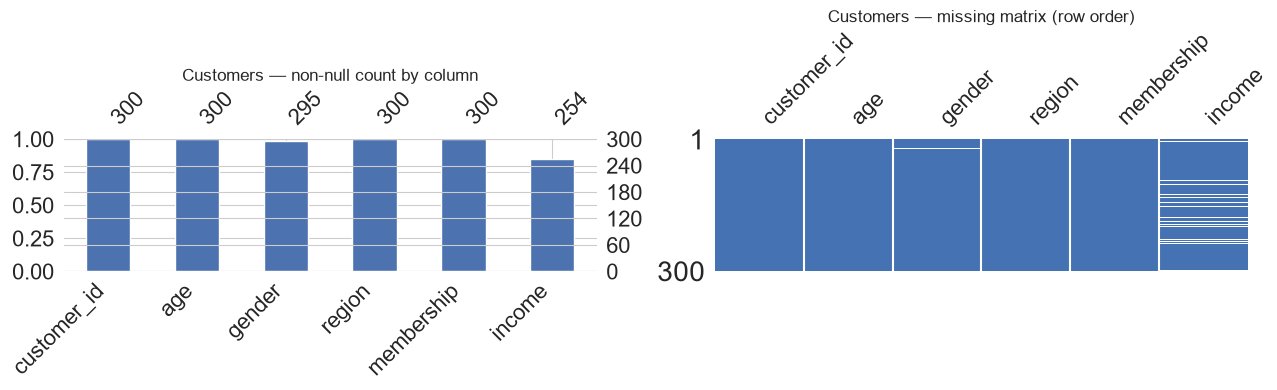

In [21]:
# 5종 세트 ⑤ — missingno로 결측 패턴 시각화 (bar + matrix)
# missingno는 결측 시각화에 특화된 라이브러리입니다. 두 가지를 자주 씁니다.
#   bar    : 컬럼별 '비어 있지 않은' 막대 — 한눈에 결측이 많은 컬럼 식별
#   matrix : 행 순서별 결측 위치 — '어디가 함께 비는가' 패턴 발견
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
msno.bar(customers, ax=axes[0], color="#4C72B0")
axes[0].set_title("Customers — non-null count by column")
msno.matrix(customers, ax=axes[1], color=(0.27, 0.45, 0.70), sparkline=False)
axes[1].set_title("Customers — missing matrix (row order)")
plt.tight_layout()
plt.show()

In [22]:
# 보너스 — 같은 행에서 두 열이 같이 비는가? 동시 결측 표
co_missing = pd.DataFrame({
    "gender_missing": customers["gender"].isnull(),
    "income_missing": customers["income"].isnull(),
})
print("동시 결측 교차표:")
print(pd.crosstab(co_missing["gender_missing"], co_missing["income_missing"]))

동시 결측 교차표:
income_missing  False  True 
gender_missing              
False             249     46
True                5      0


In [23]:
# 스스로 해보자! (3)
# 1) orders 결측 요약
# display(missing_summary(___))

# 2) amount 결측 행의 channel 분포 vs 전체 channel 분포
# null_rows = orders[orders[___].___()]
# print("결측 행 채널 분포:")
# print(null_rows["channel"].value_counts(normalize=True).round(2))
# print("\n전체 채널 분포:")
# print(orders["channel"].value_counts(normalize=True).round(2))

## 결측 유형 — MCAR · MAR · MNAR

# 4. 결측 유형 — MCAR · MAR · MNAR

Part 3의 진단으로 "income은 25% 비어 있고, app 채널 주문에서 amount 결측이 더 잦다"는 사실까지 알았습니다. 그런데 *왜* 비어 있는가에 따라 같은 결측이라도 처리 전략이 정반대가 됩니다.

- 동전 던지기처럼 *완전히 무작위*로 비었다면 → 빼도 안전합니다.
- "고소득일수록 안 적은" *원인이 있는* 결측이라면 → 빼면 평균이 낮게 왜곡됩니다.

이 차이를 통계학에서 세 가지로 분류합니다. 이름이 어렵지만 **직관은 어렵지 않습니다**.

> ❓ **이 파트에서 답할 질문:** 결측이 *왜* 생겼는가? 그 원인이 어떻게 처리 전략을 바꾸는가?

## 💡 쉽게 말하면 — 시험 답안지에 비유

학생들이 시험에서 어떤 문제를 비워두는 상황으로 비유합니다.

```text
MCAR  Missing Completely At Random
      "비운 사람과 안 비운 사람 사이에 아무 차이 없음"
      → 인쇄가 잘못 잘려나가 일부 학생만 그 문항이 안 보였다.

MAR   Missing At Random
      "비운 데에 이유는 있지만, 그 이유가 다른 컬럼으로 설명됨"
      → 외국인 학생들이 한국어 지문 문제를 비웠다. (국적이라는 다른 컬럼이 원인)

MNAR  Missing Not At Random
      "비운 이유가 *비운 값 자체*와 관련됨 — 다른 컬럼으로 설명 안 됨"
      → 모르는 학생들이 그 문제를 비웠다. (= 비워진 값 자체가 '낮은 점수'였다)
```

## 자세히 알아보기 — 비교표

| 유형 | 원인 | 진단 신호 | 안전한 처리 |
| --- | --- | --- | --- |
| **MCAR** | 완전히 무작위 | 결측이 어떤 다른 컬럼과도 상관 없음 | 제거·평균/중앙값 대체 모두 비교적 안전 |
| **MAR** | 다른 *관측된* 컬럼이 원인 | 결측 비율이 특정 그룹(채널·연령)에서 다름 | **그룹별 대체**(group-wise imputation) — 같은 채널·연령의 평균 등 |
| **MNAR** | 결측 *값 자체*가 원인 | 다른 컬럼으로 설명 안 되는 쏠림 — 어렵다 | 단순 대체는 **위험**. 결측 자체를 "이런 상태였다"는 신호로 보존하거나 별도 모델 |

> ⚠ **현실의 어려움**
> MCAR/MAR/MNAR을 100% 확실히 *증명*하는 일은 일반적으로 불가능합니다. 우리는 **데이터로 검사 가능한 신호**(다른 컬럼과의 상관)와 **도메인 지식**(왜 이 항목이 비는지에 대한 업무 이해)으로 *최선의 추정*을 합니다. 추정한 결과를 **노트북에 기록**해 둡니다 — 그래야 나중에 가설이 바뀔 때 처리를 다시 검토할 수 있어요.

> **읽는 법:** 결측 행의 `region` 분포가 전체 분포와 거의 비슷하다면, "지역 같은 다른 변수로 설명되지 않는" 결측입니다. 건수도 5건으로 매우 적어 패턴을 찾기 어렵죠. **MCAR(완전 무작위)** 로 가정해도 큰 무리가 없습니다.

> **읽는 법:** app 채널 비중이 결측 행에서 *유의미하게 더 높다*면, 결측이 채널이라는 **다른 관측 컬럼**으로 부분적으로 설명된다는 뜻입니다. 이것이 **MAR(Missing At Random)** 의 신호입니다. 처리 전략으로 "app 채널의 평균/중앙값으로 채우기"가 자연스러워집니다.

> **읽는 법:** 결측 고객 중 **VIP/premium 비중이 전체보다 높다**면, "소득이 큰(=VIP일 가능성↑) 사람일수록 안 적었다"는 가설이 살아납니다. 즉 결측 여부가 **비워진 값 자체**(income)에 의존합니다 — **MNAR** 신호입니다. 이 경우 *단순 평균 대체*는 위험합니다. 평균이 *작게 왜곡된 표본*에서 나오기 때문이에요.

## 유형이 처리 전략에 미치는 영향 — 한 장 정리

| 가정한 유형 | 추천 처리 | 피해야 할 처리 | 노트북에 적을 한 줄 예시 |
| --- | --- | --- | --- |
| MCAR | 행 제거(소량이면) / 단순 대체 | — | "5건뿐이고 다른 컬럼과 상관 없어 보임 → 행 제거" |
| MAR | **그룹별** 평균/중앙값 대체 | 전체 평균 대체(편향 유입) | "app 채널에 결측 집중 → 채널별 중앙값으로 대체" |
| MNAR | 결측 플래그 컬럼 보존 / 별도 모델 | 평균/중앙값 대체(편향 ↑) | "고소득에 결측 쏠림 의심 → 'income_missing' 플래그를 만들고 본값은 그대로 NaN 유지" |

> 💡 **개념 연결:** 다음 Part 5에서 이 표가 코드로 변신합니다. 즉 *유형 가정*이 곧 *코드 선택*입니다.

## 데이터로 확인해 봅시다

- 실무 분석가는 *완벽한 분류*에 매달리지 않습니다. **합리적인 추정**과 **그 추정의 명시적 기록**이 핵심입니다.
- 자동화된 통계 검정(Little's MCAR test 등)도 있지만, 입문 단계에서는 진단 표 + 가설 + 기록으로 충분합니다.

> 📌 **다른 산업에서는?** 헬스케어 임상시험은 환자가 약물 부작용 때문에 추적조사에 빠지는 일이 흔해서 MNAR 처리가 핵심 이슈입니다. 마케팅은 '광고를 못 본' 사용자(MAR)의 전환률을 분석에서 분리합니다. 금융 신용평가에서는 '소득 미기재'를 *별도 카테고리*로 보존(MNAR 처리)하는 경우가 많습니다.

### 스스로 해보자! ✏️ (4)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

다음 시나리오를 읽고 어떤 유형(MCAR / MAR / MNAR)인지 추측해보세요.

| 번호 | 시나리오 | 추정 유형 |
| --- | --- | --- |
| (a) | 설문지 마지막 페이지가 *제본 오류로* 일부 사람에게만 인쇄가 빠져 마지막 문항이 비었다 | ? |
| (b) | "당신의 만성 질환이 있다면 적어주세요"에 *질환이 없는* 사람들이 비웠다 | ? |
| (c) | 모바일 앱 사용자 그룹에서 *특정 화면 버그*로 인해 한 항목이 더 자주 비었다 | ? |

위 셋 중 **단순 평균 대체가 가장 위험한** 경우는 어디인가요?

### ✅ 짚고 넘어가기

1. MCAR · MAR · MNAR을 한 문장씩으로 구분해 설명할 수 있나요?
2. 데이터로 검사 가능한 신호와 도메인 지식 중, MNAR은 어느 쪽에 더 의존하나요? 왜 그럴까요?
3. MNAR로 의심될 때 *피해야* 하는 처리는 무엇인가요?

> 💡 **다음 Part 예고:** 유형에 대한 가설을 세웠습니다. 이제 가설에 맞는 *코드 선택*입니다. 다음 Part에서 제거·평균/중앙값/최빈값 대체·그룹별 대체·전·후 채움을 한 줄씩 적용하면서, 각 처리에 한 줄짜리 **근거**를 붙이는 습관을 들입니다.

In [24]:
# 모두마켓 데이터의 결측들을 유형 추정해봅시다.

# 가설 1) customers.gender — 5명만 결측 (인덱스 20~22, 70, 120) → 분포에 신호가 있나?
gender_null_mask = customers["gender"].isnull()
print("[customers.gender — 결측 5건]")
print("결측 고객의 region 분포:")
print(customers.loc[gender_null_mask, "region"].value_counts())
print("\n전체 고객의 region 분포:")
print(customers["region"].value_counts())

[customers.gender — 결측 5건]
결측 고객의 region 분포:
region
인천    2
서울    1
부산    1
대구    1
Name: count, dtype: int64

전체 고객의 region 분포:
region
부산    64
서울    62
경기    60
대구    60
인천    54
Name: count, dtype: int64


In [25]:
# 가설 2) orders.amount — channel과의 관계
amount_null = orders[orders["amount"].isnull()]
print("[orders.amount — 결측 행의 channel 분포]")
print(amount_null["channel"].value_counts(normalize=True).round(3))
print("\n[전체 channel 분포]")
print(orders["channel"].value_counts(normalize=True).round(3))

[orders.amount — 결측 행의 channel 분포]
channel
app    0.804
web    0.196
Name: proportion, dtype: float64

[전체 channel 분포]
channel
app    0.514
web    0.486
Name: proportion, dtype: float64


In [26]:
# 가설 3) customers.income — '결측 그 자체'가 값과 연결됐을 가능성
# 결측이 없는 고객만으로 income과 membership의 관계 확인 (= 평균적으로 VIP가 income이 큰가?)
income_observed = customers.dropna(subset=["income"])
print("[관측된 income — membership별 평균]")
print(income_observed.groupby("membership")["income"].mean().round(0))

# 결측이 든 고객의 membership 분포 (= '비운 사람들'은 어떤 회원이 많은가?)
income_null = customers[customers["income"].isnull()]
print("\n[income 결측 고객의 membership 분포]")
print(income_null["membership"].value_counts(normalize=True).round(2))
print("\n[전체 membership 분포]")
print(customers["membership"].value_counts(normalize=True).round(2))

[관측된 income — membership별 평균]
membership
basic      4522.0
premium    4570.0
vip        4864.0
Name: income, dtype: float64

[income 결측 고객의 membership 분포]
membership
basic      0.43
premium    0.37
vip        0.20
Name: proportion, dtype: float64

[전체 membership 분포]
membership
basic      0.60
premium    0.29
vip        0.10
Name: proportion, dtype: float64


## 결측 처리 전략 — 무엇을, 왜, 어떻게

# 5. 결측 처리 전략 — 무엇을, 왜, 어떻게

Part 4에서 유형을 추정했습니다. 이제 코드로 옮길 차례입니다. 결측을 다루는 방법은 크게 두 갈래입니다.

```text
1) 제거(Deletion)       — 결측이 든 행/열을 빼버린다
2) 대체(Imputation)     — 결측 자리에 추정값을 채워 넣는다
   ├ 단순 대체: 평균·중앙값·최빈값·고정값(0/'unknown')
   ├ 그룹별 대체: 같은 그룹의 평균·중앙값
   └ 시간 기반 채움: forward-fill / backward-fill
```

각 방법은 *언제 좋고 언제 위험한지*가 다릅니다.

> ❓ **이 파트에서 답할 질문:** 같은 결측이라도 무엇을 골라야 하고, 그 선택의 *근거*를 어떻게 한 줄로 적을 수 있을까?

## 💡 쉽게 말하면 — "치과 vs 치과의사"

치아 하나가 비면 — 치과의사는 환자의 입 상태, 나이, 다른 치아 상태를 살펴 *때울 것인가, 뽑을 것인가, 임플란트인가*를 정합니다. 데이터의 결측도 똑같습니다. 한 가지 처리법으로 모든 결측을 칠하면 *나중에 알 수 없게* 됩니다.

## 자세히 알아보기 — pandas의 결측 처리 API

| 도구 | 무엇을 하나 | 예 |
| --- | --- | --- |
| `dropna()` | 결측 행/열을 제거 | `df.dropna(subset=["amount"])` — amount가 결측인 행만 제거 |
| `fillna(값)` | 결측을 특정 값으로 채움 | `df["amount"].fillna(0)` |
| `fillna(통계량)` | 평균/중앙값/최빈값으로 채움 | `df["amount"].fillna(df["amount"].median())` |
| 그룹별 `transform("median")` | 같은 그룹 내 통계량으로 채움 | `df.groupby("channel")["amount"].transform("median")` |
| `ffill()` / `bfill()` | 앞/뒤 값으로 채움 | 시계열에서 직전 관측치로 채울 때 |
| 결측 플래그 | 결측이 *있었다*는 사실을 별도 컬럼에 보존 | `df["income_missing"] = df["income"].isnull()` |

> **언제 쓰나:** 결측 비율이 매우 낮고(보통 5% 이하), MCAR로 추정되며, 행 수가 충분할 때. **결측 비율이 높은데 무작정 제거하면** 표본이 줄고, MNAR이면 *남은 표본이 한쪽으로 쏠립니다*.

> **언제 쓰나:**
> - **평균** — 분포가 좌우 대칭일 때. 이상치에 약함.
> - **중앙값** — 분포가 한쪽으로 쏠리거나 이상치가 의심될 때. **금액·소득·수량처럼 한쪽 쏠림이 흔한 변수에 추천**.
> - **최빈값** — 범주형(성별·등급·카테고리).
> - **`'unknown'` 같은 명시 범주** — 결측 자체가 신호일 때(=MNAR 의심).

> **언제 쓰나:** Part 4에서 **MAR**이라고 추정했을 때 — "결측이 어떤 그룹(채널·연령대 등)에 쏠리며, 그 그룹의 통계가 추정값으로 합리적"이라는 판단이 설 때. 전체 평균보다 편향이 줄어듭니다.

> 💡 **개념 연결:** `groupby + transform("median")` 패턴은 내일(D+004) 그룹 연산에서 본격적으로 배웁니다. 오늘은 "결측 처리에 그룹 대체가 필요할 수 있다"는 감만 잡아도 충분합니다.

> **언제 쓰나:** 시간 순서로 정렬된 데이터에서, 결측이 *짧고* 그 사이 값이 크게 변하지 않았다고 가정할 수 있을 때. 센서·재고·주가 같은 시계열에서 자주 씁니다. (정렬되지 않은 데이터에는 의미 없음.)

> **언제 쓰나:** Part 4의 income 사례처럼 **MNAR이 의심**될 때. 단순 대체로 평균 정보를 *조용히 왜곡*시키는 대신, "결측이 있었다"는 사실을 별도 컬럼에 남겨 분석/모델이 그것을 *변수로 사용*할 수 있게 합니다.

## 의사결정 흐름도 — 한 장에 정리

```text
                  ┌───────────────────────────┐
결측 발견 → 진단(Part3) → 유형 추정(Part4) → 처리 결정(Part5)
                  └───────────────────────────┘

[결측 비율 5% 이하 AND MCAR]
   └→ dropna(subset=[col]) — 행 제거

[수치형 + MAR (결측이 그룹과 연관)]
   └→ groupby(g)[col].transform("median") 으로 그룹별 대체

[수치형 + MCAR (분포 한쪽 쏠림)]
   └→ fillna(median)

[범주형 + 결측이 적음]
   └→ fillna(mode)  또는  fillna("unknown")

[MNAR 의심]
   └→ '결측 플래그' 컬럼을 만들고, 본값은 신중히
       (단순 평균 대체는 피한다)

[시계열, 짧은 결측]
   └→ ffill / bfill
```

## 가장 중요한 한 가지 — **근거를 노트북에 적어두기**

이게 오늘의 [A] 학습 목표입니다. 처리 결과 옆에 **세 줄짜리 메모**를 남겨두세요.

> 결정: customers.income — `fillna(median)` + `income_missing` 플래그
> 근거: Part4 진단상 결측이 고소득(VIP) 쪽에 쏠려 MNAR 의심
> 한계: 평균 대체로 왜곡 가능 → 분석/모델에 플래그 컬럼을 함께 사용

## 데이터로 확인해 봅시다

- 결측 처리는 **데이터 정제 파이프라인의 첫 단계**입니다. 이후 모든 분석/모델이 이 처리 결과 위에서 동작합니다.
- **원본을 직접 수정하지 마세요.** 항상 `.copy()`로 사본을 만들고, 사본에 처리합니다. 원본은 진단·검증의 기준선입니다.

> 📌 **다른 산업에서는?** 헬스케어는 환자별 시계열에서 ffill·bfill을 자주 쓰지만, 약물 농도처럼 *시간에 민감*한 변수는 함부로 채우지 않습니다. 마케팅 분석은 채널·연령 그룹별 대체가 표준이고, 금융 신용 모델은 결측 플래그를 *변수로* 그대로 사용합니다.

> 💡 **더 알고 싶다면 (선택):** scikit-learn의 `SimpleImputer`, `KNNImputer`, `IterativeImputer`는 같은 아이디어의 자동화입니다. 단, 자동화될수록 *왜 그렇게 채워졌는지*가 보이지 않게 되므로, 입문 단계에서는 pandas로 직접 짚어보는 편이 학습에 좋습니다. D+006 파이프라인 편에서 다시 만납니다.

### 스스로 해보자! ✏️ (5)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

`orders["amount"]`의 결측을 두 가지 방식으로 처리해 결과를 비교해보세요.

1. **(따라하기)** 전체 중앙값으로 일괄 대체한 사본을 만드세요(`orders_a`).
2. **(응용)** `channel`별 중앙값으로 대체한 사본을 만드세요(`orders_b`).
3. **(생각해보기)** 두 사본의 *채널별 평균*을 각각 출력해 비교해보세요. 어느 처리가 *원본의 채널별 패턴을 덜 망가뜨릴까요*?

<details>
<summary>💡 힌트 (클릭)</summary>

```python
orders_a = orders.copy()
orders_a["amount"] = orders_a["amount"].fillna(orders_a["amount"].median())

orders_b = orders.copy()
orders_b["amount"] = orders_b["amount"].fillna(
    orders_b.groupby("channel")["amount"].transform("median")
)

print("[원본 — 결측 제외 평균]")
print(orders.groupby("channel")["amount"].mean().round(0))
print("[A — 전체 중앙값 대체]")
print(orders_a.groupby("channel")["amount"].mean().round(0))
print("[B — 채널별 중앙값 대체]")
print(orders_b.groupby("channel")["amount"].mean().round(0))
```

전체 중앙값(A)으로 채우면 채널별 평균이 *원본과 멀어지는* 경향이 있고, 채널별 중앙값(B)은 채널별 패턴을 비교적 잘 보존합니다. 이것이 MAR에서 그룹별 대체가 권장되는 이유입니다.

</details>

### ✅ 짚고 넘어가기

1. `dropna`과 `fillna`은 각각 어떤 상황에 쓰나요?
2. 평균 대체와 중앙값 대체 중, *한쪽으로 쏠린 분포*에 더 안전한 것은?
3. MNAR이 의심될 때 단순 평균 대체 대신 무엇을 고려하나요?

> 💡 **다음 Part 예고:** 결측을 다뤘으니 이제 **튀는 값**(이상치) 차례입니다. 직관적 "이상해 보이는 값"을 *정량적*으로 정의하는 방법을 배웁니다. 오늘 유일하게 수식이 등장하는 부분이에요 — 어렵지 않으니 천천히 따라오세요.

In [27]:
# 1) 제거 — 결측 행 빼기
#    원본을 망치지 않도록 항상 copy()를 사용합니다.
orders_dropped = orders.dropna(subset=["amount"]).copy()
print("원본:", orders.shape, "/ amount 결측 제거 후:", orders_dropped.shape)
print("제거된 행 수:", len(orders) - len(orders_dropped))

원본: (2000, 7) / amount 결측 제거 후: (1949, 7)
제거된 행 수: 51


In [28]:
# 2) 단순 대체 — 평균/중앙값/최빈값
demo = orders.copy()

# 중앙값으로 대체 — 한쪽으로 쏠린 분포(=평균이 이상치에 흔들림)에는 중앙값이 안전
median_amount = demo["amount"].median()
demo["amount_median"] = demo["amount"].fillna(median_amount)
print("중앙값:", median_amount)

# 최빈값(가장 흔한 범주) — 범주형(예: 성별)에 사용
mode_gender = customers["gender"].mode()[0]
print("성별 최빈값:", mode_gender)

# 고정값으로 채우기 — 범주형에 'unknown'을 카테고리로 보존
demo_c = customers.copy()
demo_c["gender_filled"] = demo_c["gender"].fillna("unknown")
print("\n[gender 처리 결과]")
print(demo_c["gender_filled"].value_counts(dropna=False))

중앙값: 59700.0
성별 최빈값: M

[gender 처리 결과]
gender_filled
M          163
F          132
unknown      5
Name: count, dtype: int64


In [29]:
# 3) 그룹별 대체 — Part 4의 MAR 가설에 맞춰 'channel별 중앙값'으로 대체
demo2 = orders.copy()

# transform은 그룹별 통계량을 '원래 행 길이로' 돌려주므로 fillna에 바로 넣을 수 있다.
group_median = demo2.groupby("channel")["amount"].transform("median")
demo2["amount_groupfill"] = demo2["amount"].fillna(group_median)

# 같은 채널 안에서 채워졌는지 확인
print("처리 전 결측 수:", demo2["amount"].isnull().sum())
print("처리 후 결측 수:", demo2["amount_groupfill"].isnull().sum())

print("\n[채널별 중앙값]")
print(orders.groupby("channel")["amount"].median())

처리 전 결측 수: 51
처리 후 결측 수: 0

[채널별 중앙값]
channel
app    59700.0
web    59700.0
Name: amount, dtype: float64


In [30]:
# 4) forward-fill / backward-fill — 시계열에서 자주 사용
ts = pd.Series([10, np.nan, np.nan, 12, np.nan, 15],
               index=pd.date_range("2025-01-01", periods=6))
print("원본:")
print(ts)
print("\nforward fill (직전 값으로 채움):")
print(ts.ffill())
print("\nbackward fill (직후 값으로 채움):")
print(ts.bfill())

원본:
2025-01-01    10.0
2025-01-02     NaN
2025-01-03     NaN
2025-01-04    12.0
2025-01-05     NaN
2025-01-06    15.0
Freq: D, dtype: float64

forward fill (직전 값으로 채움):
2025-01-01    10.0
2025-01-02    10.0
2025-01-03    10.0
2025-01-04    12.0
2025-01-05    12.0
2025-01-06    15.0
Freq: D, dtype: float64

backward fill (직후 값으로 채움):
2025-01-01    10.0
2025-01-02    12.0
2025-01-03    12.0
2025-01-04    12.0
2025-01-05    15.0
2025-01-06    15.0
Freq: D, dtype: float64


In [31]:
# 5) MNAR 의심 — 단순 대체 대신 '결측 플래그' 보존
demo3 = customers.copy()

# 플래그: 결측이었다는 사실을 새 컬럼에 보존
demo3["income_missing"] = demo3["income"].isnull().astype(int)

# 본값은 *그대로* NaN 유지 — 또는 명시적으로 '미응답' 의미를 갖는 값(예: -1)으로
# 여기서는 일단 중앙값으로 채우되, 플래그를 같이 남겨 두면 *모델/분석이 결측을 인지*할 수 있습니다.
demo3["income_filled"] = demo3["income"].fillna(demo3["income"].median())

print(demo3[["customer_id", "membership", "income", "income_missing", "income_filled"]].head(15))

   customer_id membership  income  income_missing  income_filled
0        C0001    premium  6000.0               0         6000.0
1        C0002      basic  4500.0               0         4500.0
2        C0003    premium  8500.0               0         8500.0
3        C0004        vip  3500.0               0         3500.0
4        C0005      basic  2500.0               0         2500.0
5        C0006      basic     NaN               1         4500.0
6        C0007      basic  6000.0               0         6000.0
7        C0008      basic  4500.0               0         4500.0
8        C0009    premium  6000.0               0         6000.0
9        C0010        vip  8500.0               0         8500.0
10       C0011      basic  8500.0               0         8500.0
11       C0012      basic  4500.0               0         4500.0
12       C0013      basic  8500.0               0         8500.0
13       C0014    premium  3500.0               0         3500.0
14       C0015      basic

In [32]:
# 처리 결과를 통합한 '정제된 customers' 만들기 — 결정과 근거를 코드로 옮기기
customers_clean = customers.copy()

# 1) age 이상치(0 미만 또는 120 이상)를 NaN으로 표시 — 다음 Part(이상치)에서 더 다룸
customers_clean.loc[
    (customers_clean["age"] < 0) | (customers_clean["age"] >= 120),
    "age"
] = np.nan

# 2) age 결측 → 중앙값 대체 (분포가 좌우 대칭에 가까우므로 평균도 가능)
age_median = customers_clean["age"].median()
customers_clean["age"] = customers_clean["age"].fillna(age_median)

# 3) gender 결측 → 'unknown' 범주로 보존 (MCAR로 추정되나 5건 적어 정보 손실 회피)
customers_clean["gender"] = customers_clean["gender"].fillna("unknown")

# 4) income 결측 → 결측 플래그 + 중앙값 대체 (MNAR 의심을 모델/분석이 인지하도록)
customers_clean["income_missing"] = customers_clean["income"].isnull().astype(int)
customers_clean["income"] = customers_clean["income"].fillna(customers_clean["income"].median())

print("처리 전 결측:")
print(customers.isnull().sum())
print("\n처리 후 결측:")
print(customers_clean.isnull().sum())
print("\nincome_missing 컬럼이 추가되었습니다:")
display(customers_clean[["customer_id", "age", "gender", "income", "income_missing"]].head(8))

처리 전 결측:
customer_id     0
age             0
gender          5
region          0
membership      0
income         46
dtype: int64

처리 후 결측:
customer_id       0
age               0
gender            0
region            0
membership        0
income            0
income_missing    0
dtype: int64

income_missing 컬럼이 추가되었습니다:


,customer_id,age,gender,income,income_missing
0,C0001,39.0,M,6000.0,0
1,C0002,34.0,F,4500.0,0
2,C0003,41.0,F,8500.0,0
3,C0004,49.0,M,3500.0,0
4,C0005,33.0,M,2500.0,0
5,C0006,36.0,F,4500.0,1
6,C0007,49.0,F,6000.0,0
7,C0008,42.0,M,4500.0,0


In [33]:
# 스스로 해보자! (5)
# 1) 전체 중앙값 대체
# orders_a = orders.copy()
# orders_a["amount"] = orders_a["amount"].fillna(orders_a["amount"].___())

# 2) 채널별 중앙값 대체
# orders_b = orders.copy()
# orders_b["amount"] = orders_b["amount"].fillna(
#     orders_b.groupby(___)["amount"].transform(___)
# )

# 3) 채널별 평균 비교
# print("[원본 — 결측 제외 평균]")
# print(orders.groupby("channel")["amount"].mean().round(0))
# print("[A — 전체 중앙값 대체 후]")
# print(orders_a.groupby("channel")["amount"].mean().round(0))
# print("[B — 채널별 중앙값 대체 후]")
# print(orders_b.groupby("channel")["amount"].mean().round(0))

## IQR 이상치 탐지 — 정상 범위의 경계 긋기

# 6. IQR 이상치 탐지 — 정상 범위의 경계 긋기

어제(D+002) `describe()`에서 `customers.age`의 max가 999, `orders.quantity`의 max가 100으로 나왔습니다. 사람 눈에는 "이상해 보이는" 값이죠. 그런데 **얼마나 이상한가**를 어떻게 *숫자로* 정할까요? 이를 정의하지 않으면 분석가마다 처리 기준이 달라져 결과를 비교할 수 없습니다.

> ❓ **이 파트에서 답할 질문:** "정상"과 "이상"을 가르는 *수학적인 선*을 어떻게 그을 수 있을까?

## 💡 쉽게 말하면 — 가운데 50%의 폭으로 경계를 정한다

이상치 탐지에 가장 널리 쓰이는 방법이 **IQR(Interquartile Range, 사분위 범위)** 입니다.

```text
값들을 작은 순서대로 줄 세우면:

        Q1                  Q2(중앙값)              Q3
  □□□□  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓  □□□□
  ↑ 하위 25%    ↑   가운데 50% (IQR)    ↑     상위 25%
            정상 범위를 가운데 50%의 폭(IQR)으로 정한다.
```

가운데 50%의 폭(Q3 − Q1)을 **IQR**이라 부르고, 그 폭의 1.5배만큼 좌우로 더 넓힌 구간 밖을 **이상치**로 봅니다.

## 자세히 알아보기 — IQR 공식

수식이 처음 등장하는 자리입니다. 기호 하나하나 풀어 적습니다.

$$
\text{IQR} = Q_3 - Q_1
$$

$$
\text{하한}(\text{lower fence}) = Q_1 - 1.5 \times \text{IQR}
$$

$$
\text{상한}(\text{upper fence}) = Q_3 + 1.5 \times \text{IQR}
$$

| 기호 | 의미 |
| --- | --- |
| $Q_1$ | 25% 분위수 (1사분위) — 하위 25%와 상위 75%를 가르는 값 |
| $Q_2$ | 50% 분위수 = **중앙값**(median) |
| $Q_3$ | 75% 분위수 (3사분위) — 하위 75%와 상위 25%를 가르는 값 |
| $\text{IQR}$ | $Q_3 - Q_1$. *가운데 50%*가 차지하는 폭 |
| 하한·상한 | 정상 범위의 경계. 이 밖은 이상치로 판정 |

> **왜 1.5인가?**
> 정규분포에서 상한/하한 밖에 떨어질 확률이 약 0.7%로 작아지도록 경험적으로 정해진 값입니다(통계학자 튜키, 1977). **절대적인 법칙이 아니라 합의된 기준**입니다. 더 엄격하게 보고 싶으면 3을 쓰기도 합니다.

> 💡 **개념 연결:** 박스플롯의 상자는 $Q_1$~$Q_3$, 상자 끝에서 뻗는 수염이 보통 IQR의 1.5배 이내까지입니다. 어제 그렸던 박스플롯의 점들이 바로 이 기준의 이상치였습니다 — 어제는 *그림으로* 보고 오늘은 *수식으로* 잡습니다.

> **읽는 법:** Part 0에서 일부러 심어둔 `quantity = 100`과 `quantity = 50` 두 건이 잡혀야 합니다. *진짜로 큰 주문*일 수도 있고 *입력 실수*일 수도 있습니다 — 처리는 다음 Part에서 결정합니다.

> **읽는 법:** 의도적으로 심어둔 999, -3, 120이 모두 경계 밖으로 잡힙니다. **불가능한 값**(음수, 999살)과 **그저 큰 값**(120살)이 같은 도구에서 함께 잡히는 점에 주의하세요 — *탐지*와 *처리 방침*은 분리됩니다(다음 Part).

> 💡 **개념 연결:** Part 2의 *조건 만족 행의 특정 열만 가리키기* 패턴이 여기서 그대로 쓰입니다. `df.loc[mask, "age"] = np.nan` 한 줄로 탐지된 이상치들을 결측으로 표시할 수 있어요 — 그러면 Part 5의 결측 처리 도구들이 그대로 이어집니다.

> **읽는 법:** 박스플롯의 양 끝 수염을 넘어가는 점들이 IQR 1.5배 기준 이상치입니다. **수식**($Q_1, Q_3, IQR$)과 **그림**(박스플롯의 수염)이 정확히 같은 정보를 다른 방식으로 보여주고 있습니다.

## IQR의 강점과 한계

| 강점 | 한계 |
| --- | --- |
| 분포 가정 없이 적용 가능(정규분포 아니어도 OK) | 한쪽으로 매우 쏠린 분포(매출·소득)에선 과탐 가능 |
| 한 줄로 계산 가능, 박스플롯과 호환 | "왜 이상한가"의 *원인*은 알려주지 못함 |
| 1.5라는 합의된 기준 | 비즈니스 임계(예: 환불액 100만원 이상)와 다를 수 있음 |

> ⚠ **수치형에만 적용됩니다.** 범주형(채널·등급)에는 IQR을 쓰지 않습니다. 범주형 이상치는 보통 *드물게 등장하는 값*(예: app만 0.5% 등장)을 찾는 빈도 분석으로 다룹니다.

## 데이터로 확인해 봅시다

- 분석가가 처음 받은 수치형 컬럼에 *기본 점검*으로 IQR을 한 번씩 돌립니다.
- 탐지 결과는 **자동 제거하지 않습니다.** 일단 *플래그*만 달고, 처리 방침은 비즈니스 맥락으로 결정합니다(다음 Part).

> 📌 **다른 산업에서는?** 금융 거래 모니터링은 이상치 탐지가 곧 *부정 거래 후보*입니다. 제조는 불량품 후보, 헬스케어는 측정 오류 후보. 같은 IQR 도구가 산업마다 *해석*은 완전히 다릅니다.

> 💡 **더 알고 싶다면 (선택):** 분포가 정규에 가깝다고 가정할 수 있다면 **Z-점수**(표준편차 기반)도 자주 씁니다. $z = (x - \mu) / \sigma$가 보통 |z| > 3이면 이상치. 분포 가정이 필요한 점이 IQR과의 가장 큰 차이입니다. 통계 모듈에서 더 다룹니다.

### 스스로 해보자! ✏️ (6)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

`orders["amount"]`에 대해 IQR로 이상치를 탐지해보세요.

1. **(따라하기)** $Q_1$, $Q_3$, IQR, 하한, 상한을 출력하세요.
2. **(응용)** 이상치 행을 골라 개수와 비율을 출력하세요.
3. **(생각해보기)** 우리 데이터에는 amount가 5,000,000짜리 한 건이 의도적으로 심어져 있습니다. 이걸 *제거*하기 전에 분석가가 **확인해야 할 것**은 무엇일까요?

<details>
<summary>💡 힌트 (클릭)</summary>

```python
mask_amt, (lo, up) = detect_outliers_iqr(orders["amount"])
print(f"하한: {lo:.0f} / 상한: {up:.0f}")

n_out = mask_amt.sum()
print(f"이상치: {n_out}건 ({n_out/len(orders)*100:.2f}%)")
display(orders[mask_amt].head())
```

3번 답: **그 주문이 *왜* 그렇게 큰지** — `customer_id`, `quantity`, `product_id`, `category`를 확인해야 합니다. 실제 *대량 구매(B2B 주문, 기업 거래)* 일 수도 있고, *입력 단위 실수(원 → 천원)* 일 수도 있습니다. 같은 5,000,000원이 두 해석에서 처리 방침이 정반대입니다. 이것이 다음 Part 7의 주제입니다.

</details>

### ✅ 짚고 넘어가기

1. IQR의 정의를 한 줄로 말할 수 있나요? $Q_1$, $Q_3$가 무엇인지 함께요.
2. 하한/상한 공식을 노트에 쓰지 않고 머리로 떠올릴 수 있나요? ($\pm 1.5 \times \text{IQR}$)
3. IQR은 어떤 자료형에 적용되나요? 안 되는 경우는 무엇인가요?

> 💡 **다음 Part 예고:** 탐지는 끝났습니다. 이제 가장 어려운 일 — **처리 방침**. 같은 999살, 같은 5,000,000원이라도 *어떤 비즈니스 맥락*인지에 따라 제거·대체·유지 결정이 갈립니다.

In [34]:
# IQR 한 줄로 계산해보기 — orders.quantity
q1 = orders["quantity"].quantile(0.25)
q3 = orders["quantity"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(f"Q1 = {q1}")
print(f"Q3 = {q3}")
print(f"IQR = Q3 - Q1 = {iqr}")
print(f"하한(lower fence) = Q1 - 1.5*IQR = {lower}")
print(f"상한(upper fence) = Q3 + 1.5*IQR = {upper}")

Q1 = 1.0
Q3 = 2.0
IQR = Q3 - Q1 = 1.0
하한(lower fence) = Q1 - 1.5*IQR = -0.5
상한(upper fence) = Q3 + 1.5*IQR = 3.5


In [35]:
# 정의한 경계로 이상치 골라내기
outlier_mask = (orders["quantity"] < lower) | (orders["quantity"] > upper)
outliers = orders[outlier_mask]
print(f"이상치 개수: {len(outliers)}건 (전체의 {len(outliers)/len(orders)*100:.2f}%)")
display(outliers[["order_id", "category", "quantity", "amount"]])

이상치 개수: 2건 (전체의 0.10%)


,order_id,category,quantity,amount
7,O00008,뷰티,100,29900.0
1900,O01901,뷰티,50,29900.0


In [36]:
# IQR을 재사용 가능한 함수로 만들기 — 분석가의 일상 도구
def detect_outliers_iqr(series, k=1.5):
    '''IQR 방법으로 이상치 마스크와 경계를 반환합니다.

    Parameters
    ----------
    series : pd.Series  — 수치형 시리즈
    k      : float      — 경계 폭의 IQR 배수 (기본 1.5, 더 엄격하게 보려면 3)

    Returns
    -------
    mask   : pd.Series(bool)  — 이상치 위치 (True)
    bounds : (lower, upper)   — 경계값
    '''
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    mask = (series < lower) | (series > upper)
    return mask, (lower, upper)

# 사용 예 — age에 적용
mask_age, (lo, up) = detect_outliers_iqr(customers["age"])
print(f"age 경계: ({lo:.1f}, {up:.1f}) / 이상치 수: {mask_age.sum()}")
display(customers.loc[mask_age, ["customer_id", "age", "membership"]])

age 경계: (11.0, 59.0) / 이상치 수: 5


,customer_id,age,membership
5,C0006,999,basic
10,C0011,-3,basic
15,C0016,120,basic
209,C0210,70,basic
262,C0263,6,basic


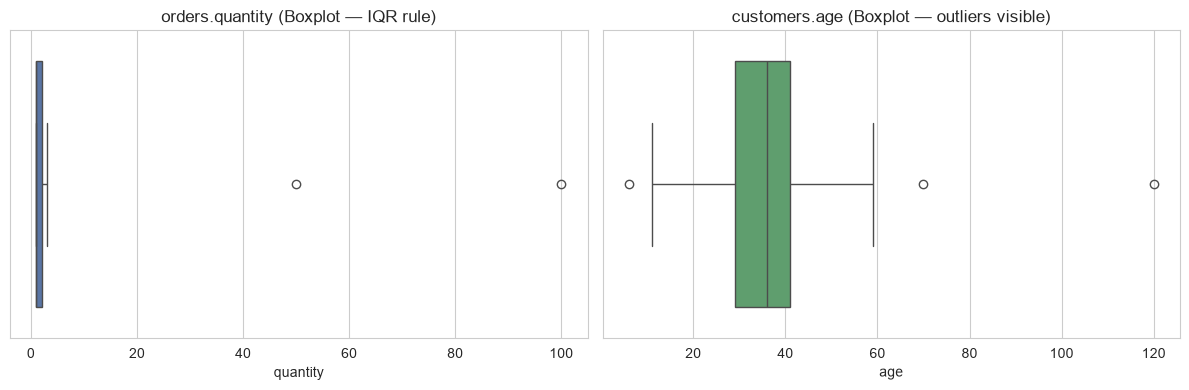

In [37]:
# 시각화로 다시 확인 — 박스플롯이 곧 IQR의 그림 표현
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=orders["quantity"], ax=axes[0], color="#4C72B0")
axes[0].set_title("orders.quantity (Boxplot — IQR rule)")
axes[0].set_xlabel("quantity")

# age는 999가 그림을 망가뜨리므로 양호 범위만 그려 비교
sns.boxplot(x=customers.loc[customers["age"].between(0, 120), "age"], ax=axes[1], color="#55A868")
axes[1].set_title("customers.age (Boxplot — outliers visible)")
axes[1].set_xlabel("age")

plt.tight_layout()
plt.show()

In [38]:
# 스스로 해보자! (6)
# 1) IQR 경계
# mask_amt, (lo, up) = detect_outliers_iqr(orders[___])
# print(f"하한: {lo:.0f} / 상한: {up:.0f}")

# 2) 이상치 개수·비율
# n_out = mask_amt.sum()
# print(f"이상치: {n_out}건 ({n_out/len(orders)*100:.2f}%)")
# display(orders[mask_amt].head())

## 이상치 처리 의사결정 — 비즈니스가 답을 정한다

# 7. 이상치 처리 의사결정 — 비즈니스가 답을 정한다

Part 6에서 *이상해 보이는* 값을 찾는 도구를 만들었습니다. 하지만 도구는 "이게 이상하다"고만 말하지, "어떻게 해야 한다"고 알려주진 않습니다. 그건 분석가와 도메인 전문가의 몫입니다.

> ❓ **이 파트에서 답할 질문:** 같은 이상치라도 무엇을 근거로 *제거·대체·유지* 중 하나를 고를 수 있을까?

## 💡 쉽게 말하면 — 사람·실수·신호

이상치는 보통 셋 중 하나입니다.

```text
1) 입력 실수    — 999살 고객, '5,000,000원'의 단위 오류
                  → 보통 결측(NaN)으로 만들고 결측 처리 규칙으로 흡수
2) 진짜 극단    — VIP의 100건 주문, 실제 거래
                  → '진짜 사실'이므로 **유지** (분석에서는 별도 세그먼트)
3) 모델 시그널 — 부정 거래, 장비 고장 직전
                  → 오히려 분석의 *핵심 대상*. 제거하면 안 된다.
```

같은 *2,500만원 주문*이 (1)이면 입력 실수, (2)면 기업 고객, (3)이면 카드 도난 — 세 처리가 정반대입니다.

## 자세히 알아보기 — 처리 옵션 3종

| 옵션 | 어떻게 | 언제 |
| --- | --- | --- |
| **제거** | `df.loc[mask, "col"] = np.nan` 후 결측 처리 또는 `dropna` | 입력 실수가 명백, 비즈니스적으로 의미 없음 |
| **대체(클리핑)** | 경계값으로 잘라 채움(`clip`) | 분포는 보존하되 극단 영향을 줄이고 싶을 때 |
| **유지** | 그대로 두되 **이상치 플래그** 컬럼을 별도로 | 진짜 극단이거나, 자체가 분석의 신호 |

> ⚠ **자동 제거는 가장 위험합니다.** "IQR로 잡혔으니 다 빼자"는 흔한 실수예요. 어떤 데이터셋에서는 "이상치"가 *데이터 자체의 의미*입니다(부정 거래 탐지에서 정상 거래만 남기면 모델이 작동 안 함).

> **언제:** 999, -3 같은 *물리적으로 불가능한 값*. 도메인 지식("사람은 0~120세")으로 명확히 판단 가능. 이때는 *제거*가 안전합니다.

> **언제:** 분포의 모양은 보존하되, *극단 영향*만 줄이고 싶을 때(특히 평균·표준편차를 안정시키고 싶은 모델 입력). 단, **본래 값을 잃어버리므로** "원본도 함께 보관"하는 습관이 필요합니다.

> **언제:** 진짜 극단(=비즈니스적으로 의미 있는 큰 거래), 또는 결정 보류 단계. 플래그를 두면 분석/모델이 *그 값이 이상치였다*는 정보를 함께 사용합니다.

## 의사결정 흐름도

```text
[이상치 탐지(Part 6)] → 한 번에 보지 않고 *건별로* 판단

  Q1) 물리적으로 불가능한 값인가? (음수 나이, 999살)
       └ Yes → ① 제거(NaN 표시 → 결측 처리)

  Q2) 입력 단위 실수 의심? (가격 단위, 통화 단위)
       └ Yes → 원본 추적 후 ① 또는 ② 클리핑

  Q3) 진짜 큰 거래(=비즈니스적 사실)인가? B2B? VIP?
       └ Yes → ③ 유지 + 플래그 (분석에서 세그먼트 분리)

  Q4) 이상치 자체가 분석 대상(부정 거래 탐지 등)?
       └ Yes → ③ 유지. 절대 제거 금지

  결정 불가 → ③ 유지 + 플래그 (가장 안전한 기본값)
```

> 💡 **가장 중요한 한 줄:** "결정 못 하겠으면 *유지 + 플래그*가 기본값입니다." 정보를 *지우지 않는* 보수적인 처리가 안전합니다.

## 결정과 근거를 노트북에 기록하기

오늘의 [A] 학습 목표를 한 번 더. 처리 코드 옆에는 다음 세 줄을 붙이세요.

> **결정**: orders.amount — 클리핑하지 않고 **유지 + 플래그**
> **근거**: 5,000,000원 1건이 IQR 기준 이상치지만, 카테고리(가전)·수량 1을 보면 *고가 가전*의 정상 거래로 보임
> **한계**: 1건만으로 판단했고 customer_id의 과거 이력은 확인 못 함 → 데이터 추가 확보 시 재검토

## 데이터로 확인해 봅시다

- 처리 코드는 *짧지만* 결정의 무게는 큽니다. 매번 *세 줄짜리 메모*(결정·근거·한계)를 남기세요.
- 이상치 처리는 **재실행이 항상 가능해야** 합니다. 원본을 두고 사본에 처리한 다음, 처리 코드는 셀로 분리해서 *언제든 다른 기준으로 재처리*할 수 있게 합니다.

> 📌 **다른 산업에서는?** 금융 사기 탐지에서는 IQR 이상치가 **타깃**입니다(제거 금지). 제조 품질 관리에서는 이상치가 *불량 후보*라 별도 라인으로 분류합니다. 마케팅은 *VVIP의 큰 구매*를 별도 세그먼트로 두지, 평균에 섞지 않습니다.

> 💡 **더 알고 싶다면 (선택):** 이상치 *탐지* 자체를 자동화하는 모델로는 Isolation Forest, Local Outlier Factor 등이 있습니다. 다변량 환경에서 IQR이 잡지 못하는 *조합 이상*까지 잡습니다. 입문 단계에서는 IQR + 도메인 지식의 조합으로 충분합니다.

### 스스로 해보자! ✏️ (7)

> 정답은 하나가 아닙니다. 일단 실행해보세요.

다음 네 사례에 *처리 결정*을 정하고 *근거*를 한 줄씩 적어보세요. 정해진 정답이 아니라 *판단과 기록*이 핵심입니다.

| # | 사례 | 처리(제거/클리핑/유지+플래그) | 근거(한 줄) |
| --- | --- | --- | --- |
| 1 | `customers.age = 999` | ? | ? |
| 2 | `customers.age = 120` (희귀하지만 가능) | ? | ? |
| 3 | `orders.amount = 5,000,000` (가전 카테고리) | ? | ? |
| 4 | `orders.quantity = 100` (일반 소비자) | ? | ? |

### ✅ 짚고 넘어가기

1. 이상치 처리 3옵션(제거·클리핑·유지+플래그)을 한 줄씩 말할 수 있나요?
2. "결정 못 하겠을 때의 기본값"은 무엇인가요? 왜 그게 가장 안전한가요?
3. 이상치 처리 결과 옆에 *세 줄짜리 메모*에는 무엇이 들어가나요?

> 💡 **다음 단계 예고:** 도구도 익혔고 결정 방법도 익혔습니다. 이제 두 가지를 한 번에 써서 **오염된 단일 테이블을 정제하고**, 결정 근거를 정리한 **분석가의 정제 리포트**를 작성해봅시다.

# 🧪 종합 실습 — 오염된 단일 테이블 정제 + 판단 근거 기록

오늘의 마무리입니다. 새 데이터셋(가상의 *모두마켓 협력사* "옷장패션"의 주문 데이터)을 받았다고 가정합니다. 오염이 더 다양하게 심어져 있어, 진단·결정·처리의 전체 흐름을 한 번에 굴려볼 수 있습니다.

> 💡 시나리오 3개 → 마무리 1개의 순서로 진행합니다. 각 시나리오에서 *결정과 근거*를 노트북 마크다운 셀에 한 줄씩 남기세요. 그것이 오늘의 최종 산출물이 됩니다.

## 시나리오 1 — 진단 (Part 3·6의 도구를 한 번에)

받은 데이터를 어제 배운 `shape`·`info`·`describe`로 한 번 보고, 오늘 배운 결측 진단(`isnull().sum()`/비율/행별)과 IQR 이상치 탐지를 빠르게 적용하세요.

아래 셀을 실행한 뒤, *진단 결과 한 장*을 마크다운으로 정리해보세요.

**시나리오 1 정리 — 진단 결과 한 장 (예시 양식)**

> - **규모**: 1,500행 × 7열
> - **결측**: amount(약 3%, app 채널에 쏠림 → MAR 의심), price(0.3%, 소수 — MCAR 가능)
> - **이상치(IQR)**: customer_age(999·0 — 입력 실수), quantity(200 — 도매?), amount(50,000,000 — 단일 거래)

여러분의 데이터에서 본 결과로 직접 채워 넣어 보세요.

## 시나리오 2 — 처리 결정 (Part 4·5·7의 의사결정)

이제 *결정*입니다. 각 결측·이상치에 대해 처리 옵션과 한 줄 근거를 정해보세요. 아래는 *예시 결정 양식*이며, 실제 결정은 분석가의 판단입니다.

**예시 결정 양식 (마크다운 셀로 노트북에 남기세요)**

| 컬럼·이슈 | 결정 | 근거(한 줄) | 한계(한 줄) |
| --- | --- | --- | --- |
| `amount` 결측 | 채널별 중앙값 대체 | app 결측 비율↑ → MAR 가설에 부합 | 채널 외 다른 원인은 검토 안 함 |
| `price` 결측 | 카테고리별 중앙값 대체 | 비율 0.3%로 적음, 카테고리별 가격대 보존 | 표본 적어 카테고리 통계 불안정 |
| `customer_age = 999, 0` | NaN 표시 → 중앙값 대체 | 물리적 불가능 — 입력 실수 추정 | 외부 인증 데이터 없음 |
| `quantity = 200` | NaN 표시 → 중앙값 대체 | 일반 소비자 도메인 외 값 | 만약 도매 가능 고객이면 제거가 손실 |
| `amount = 50,000,000` | 유지 + `amount_outlier` 플래그 | 1건의 비즈니스적 가능성 보존 | 도매면 별도 분석 필요 |

> 💡 양식은 자유이지만 **결정·근거·한계** 세 항목이 핵심입니다.

## 시나리오 3 — 처리 코드 작성

위 결정을 코드로 옮깁니다. *원본을 두고 사본에 처리*하고, 처리 끝에 검증 출력을 남기세요.

## 📊 정제 보고서 작성 (제출물)

지금까지의 진단·결정·처리를 아래 **양식**에 맞춰 마크다운 셀로 작성하세요. 이것이 오늘의 최종 산출물이며, GitHub에 제출합니다.

```markdown
# 옷장패션 데이터 정제 보고서

## 1. 데이터 개요
- 행/열: 1,500 × 7
- 주요 컬럼: order_id, customer_age, category, channel, price, quantity, amount, return_amount

## 2. 진단 결과
- 결측: amount ___%, price ___%, ...
- 이상치(IQR): customer_age(999·0, ___건), quantity(200, ___건), amount(50,000,000, ___건)
- 의심되는 결측 유형: amount는 app 채널에 쏠림 → MAR

## 3. 처리 결정과 근거
| 이슈 | 결정 | 근거 | 한계 |
| --- | --- | --- | --- |
| amount 결측 | 채널별 중앙값 대체 | MAR 가설 부합 | ... |
| ... | ... | ... | ... |

## 4. 처리 후 검증
- 결측 0건(설계상 NaN 유지가 필요한 컬럼 제외)
- customer_age 범위: __ ~ __ (정상)
- amount_outlier 플래그 ___건 보존

## 5. 후속 권고
- (도매 가능 고객 식별을 위해 customer_id 단위 과거 이력 확보 필요 등)
```

> 💡 **점수 기준은 정확성·합리성·인사이트 세 축입니다.** 코드가 돌고, 결정이 타당하고, 결정의 *근거를 남겼는가*. 정답이 아니라 *판단의 흔적*이 평가의 대상입니다.

# ✅ 오늘의 퀴즈

배운 내용을 잠깐 확인해볼게요. 틀려도 괜찮습니다. "이런 걸 배웠지" 하고 떠올리는 용도예요.

### 개념 퀴즈

1. `.loc[0:3]`과 `.iloc[0:3]`는 각각 몇 개 행을 반환하나요? 왜 다를까요?
2. 결측의 세 유형 중 *"비운 사람과 안 비운 사람 사이에 아무 차이 없음"*에 해당하는 것은?
   `(a) MCAR  (b) MAR  (c) MNAR`
3. IQR로 정한 이상치의 상한 공식은?
   `(a) Q3 + 1.5*IQR  (b) mean + 3*std  (c) Q3 + IQR`
4. **MNAR 의심**일 때 *피해야 할* 처리는?
   `(a) 단순 평균 대체  (b) 결측 플래그 보존  (c) 단순 제거`
5. 이상치 처리에서 "결정 못 하겠을 때의 기본값"은?
   `(a) 자동 제거  (b) 유지 + 플래그  (c) 평균 대체`

### 코드 퀴즈

`orders`에서 다음 조건을 만족하는 정제 결과를 만들어보세요.
1. `quantity`의 IQR 이상치를 NaN으로 표시
2. `amount`의 결측을 **채널별 중앙값**으로 대체
3. 처리 후 `amount`와 `quantity`의 결측이 0인지 확인 출력

> **읽는 법:** `detect_outliers_iqr`로 탐지 → `.loc[mask, ...] = np.nan`로 결측 표시 → `fillna(중앙값)`. **이상치 처리는 결국 결측 처리로 흡수**됩니다. 두 주제를 따로 배웠지만, 코드 위에선 한 파이프라인입니다.

# 🎓 정리 & 다음 시간 예고

## 오늘 배운 것이 어떻게 이어졌나

```text
[Part 1] 인덱싱 3종         원하는 행·열을 정확히 가리키기
   ↓  (조건 만족 행의 특정 열에만 값 대입 — 모든 처리의 기본 패턴)
[Part 2] 불리언 필터링 심화  isin·between·query, 그리고 결측의 함정
   ↓  (NaN과의 비교는 항상 False → 결측을 명시적으로 다루기)
[Part 3] 결측 패턴 진단      어디가, 어떻게 비었는가
   ↓  (5종 진단 세트로 패턴을 표·그림으로 정리)
[Part 4] 결측 유형           왜 비었는가 — MCAR · MAR · MNAR
   ↓  (가설이 처리 코드 선택을 결정)
[Part 5] 결측 처리 전략      제거 · 대체 · 그룹별 · 플래그
   ↓  (의사결정 흐름도 + 근거 한 줄 기록)
[Part 6] IQR 이상치 탐지     수식으로 정상/이상 경계 긋기
   ↓  (수식·박스플롯·코드의 동일성)
[Part 7] 이상치 처리 결정    제거 · 클리핑 · 유지+플래그
   ↓  (비즈니스 맥락이 결정한다)
[종합 실습] 옷장패션 데이터 정제 + 정제 보고서
```

## 한 장 정리표

| 주제 | 핵심 한 줄 | 대표 코드 |
| --- | --- | --- |
| 인덱싱 3종 | 라벨/위치/조건 — 목적이 다름 | `df.loc[mask, "col"] = 값` |
| 필터링 심화 | 다중 조건은 `isin`·`between`·`query`로 | `df.query("...")` |
| 결측 진단 | 열별·행별·동시 결측의 패턴을 본다 | `df.isnull().mean()` |
| 결측 유형 | MCAR·MAR·MNAR — 처리 전략이 갈린다 | (가설 + 도메인 지식) |
| 결측 처리 | 제거·평균/중앙값·그룹별·플래그 | `groupby().transform("median")` |
| IQR 이상치 | $Q_3 + 1.5 \cdot \text{IQR}$ 밖이 이상 | `series.quantile(0.25/0.75)` |
| 이상치 처리 | 제거·클리핑·유지+플래그 — 기본값은 유지 | `series.clip(lower, upper)` |
| 기록 습관 | 결정·근거·한계 세 줄 | (마크다운 셀) |

## 진단 → 다음 분석 도구 매핑

오늘 진단·처리한 결과가 내일·모레의 학습으로 자연스럽게 이어집니다.

| 오늘 발견·결정 | 자연스러운 다음 분석 |
| --- | --- |
| `orders`만 정제하면 분석이 부족 — `customers`·`products`와 함께 봐야 | **테이블 병합·집계 — D+004** |
| 표기 혼재(`app`/`APP`), 날짜 포맷 혼재가 남아 있음 | **문자열·날짜 처리 — D+005** |
| 결측·이상치 처리를 매번 손으로? 자동화해야 함 | **함수·파이프라인 자동화 — D+006** |
| 큰 데이터에서도 IQR이 빠르게 돌까? | **대용량·Polars — D+007** |
| 처리 *전후* 분포 비교를 그림으로 확인 | **시각화 심화 — D+008** |

## 🎓 다음 시간 예고

> **"한 테이블을 고쳤으니, 이제 여러 테이블을 합친다."**
>
> 오늘 우리는 `orders` 한 테이블을 정제했습니다. 그러나 실무 분석은 *여러 테이블의 결합*에서 시작됩니다 — 매출은 `orders`에, 고객 정보는 `customers`에, 상품 정보는 `products`에 각각 흩어져 있죠. 다음 시간에는 이 **흩어진 테이블을 하나의 인사이트로 합치는** `merge`·`concat`·`groupby`·`pivot_table`을 만납니다. 오늘 익힌 *조건 만족 행의 정밀 처리* 패턴은 그때도 그대로 쓰입니다.

# 📝 오늘의 과제

오늘 만든 **옷장패션 정제 보고서**를 다듬어 GitHub에 제출합니다.

## 제출물

1. 종합 실습의 옷장패션 데이터를 진단·정제한 노트북(`.ipynb`)
2. 마무리 양식을 채운 **정제 보고서**(노트북 안 마크다운 셀로 작성)

## 필수 과제

- [ ] 결측 진단 5종 세트(열별 수·비율·행별·특정 열 결측 행·히트맵)를 모두 적용했다.
- [ ] 각 결측의 **유형(MCAR·MAR·MNAR)**을 가설로 추정하고 한 줄 근거를 적었다.
- [ ] IQR로 수치형 컬럼의 이상치를 탐지했다.
- [ ] 결측·이상치 각각에 처리 결정과 한 줄 근거·한계를 적었다.
- [ ] 처리 *전후* 비교 출력(결측 수, 통계량)을 노트북에 남겼다.

## 심화 과제 (선택)

- [ ] 같은 결측을 **두 가지 다른 방법**(예: 평균 대체 vs 채널별 중앙값 대체)으로 처리해, 결과 통계량이 어떻게 달라지는지 한 표로 비교했다.
- [ ] `amount` 박스플롯을 *처리 전후*로 두 개 그려, 클리핑/플래그 정책이 시각적으로 어떻게 다른지 확인했다.
- [ ] 본인이 관심 있는 *다른 산업의 데이터*에 같은 절차를 적용해보고, 우리 도메인과의 차이를 한 단락 적었다.

## 제출 방법 (GitHub)

개인 포트폴리오 저장소(공개)에 `D003/` 폴더를 만들어 노트북을 올립니다.

```bash
# 1주차는 main에 바로 올려도 됩니다. 2주차부터 PR 흐름을 익혀요.
git add D003/
git commit -m "D003 결측·이상치 정제 보고서 제출"
git push origin main
```

## 평가 기준

| 축 | 무엇을 보나 |
| --- | --- |
| 정확성 | 진단·처리 코드가 오류 없이 돌고, 통계량이 맞는가 |
| 합리성 | 결측 유형 가설과 처리 결정이 데이터·도메인 맥락에 부합하는가 |
| 인사이트 | 결정의 **근거와 한계**가 한 줄씩 명시되었는가(이게 오늘의 핵심!) |

> 💡 모두의연구소의 과제는 순위를 매기지 않습니다. **"어제의 나보다 *판단을 더 잘 기록*하게 되었는가"** 가 기준이에요. 코드와 인사이트를 동료와 공유하며 함께 성장합니다.

---

수고하셨습니다! 🎉

오늘 여러분은 데이터 분석가의 두 번째 행동, **"코드보다 *판단*과 그 *기록*이 먼저"** 를 익혔습니다. `.loc`·`.iloc`·불리언을 자유롭게 다루게 됐고, 결측·이상치를 *왜 그렇게 처리했는지* 한 줄로 적는 습관까지 만들었습니다.

내일은 "흩어진 테이블을 하나로 묶는" 본격 분석의 세계에서 만나요. 결정의 근거를 남기는 손, 그게 분석가의 가장 큰 자산입니다. 🚀

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 교안은 생성형 AI를 활용해 제작하고 제작자가 검수했습니다.<br>
무단 복제 및 배포를 금합니다.</sub>

In [39]:
# 옵션 ① 제거 (정확히는 'NaN 표시 후 결측 처리'로 연결)
demo_a = customers.copy()

# 사람 나이로 비현실적인 값을 결측으로 표시
unrealistic = (demo_a["age"] < 0) | (demo_a["age"] > 110)
demo_a.loc[unrealistic, "age"] = np.nan

# 이제 Part 5의 결측 처리가 그대로 이어진다 — 중앙값 대체
demo_a["age"] = demo_a["age"].fillna(demo_a["age"].median())

print("처리 전 age 통계:")
print(customers["age"].describe()[["min", "max", "mean"]].round(2))
print("\n처리 후 age 통계:")
print(demo_a["age"].describe()[["min", "max", "mean"]].round(2))

처리 전 age 통계:
min      -3.00
max     999.00
mean     38.37
Name: age, dtype: float64

처리 후 age 통계:
min      6.00
max     70.00
mean    35.01
Name: age, dtype: float64


In [40]:
# 옵션 ② 클리핑(clip) — 분포의 양 끝을 경계값으로 '잘라' 영향 축소
demo_b = orders.copy()
q1 = demo_b["amount"].quantile(0.25)
q3 = demo_b["amount"].quantile(0.75)
iqr = q3 - q1
lo, up = q1 - 1.5*iqr, q3 + 1.5*iqr

# clip — 경계 밖 값을 경계값으로 대체
demo_b["amount_clipped"] = demo_b["amount"].clip(lower=lo, upper=up)

print("처리 전 amount max:", orders["amount"].max())
print("처리 후 amount_clipped max:", demo_b["amount_clipped"].max())

# 큰 5건 비교
display(
    pd.DataFrame({
        "amount": orders["amount"].nlargest(5).values,
        "amount_clipped": demo_b["amount_clipped"].nlargest(5).values,
    })
)

처리 전 amount max: 5000000.0
처리 후 amount_clipped max: 280200.0


,amount,amount_clipped
0,5000000.0,280200.0
1,389700.0,280200.0
2,389700.0,280200.0
3,389700.0,280200.0
4,389700.0,280200.0


In [41]:
# 옵션 ③ 유지 + 플래그 — 가장 안전한 기본값
demo_c = orders.copy()
mask, (lo, up) = detect_outliers_iqr(demo_c["amount"])
demo_c["amount_outlier"] = mask.astype(int)

print("이상치 플래그 분포:")
print(demo_c["amount_outlier"].value_counts())

print("\n[유지된 이상치 행]")
display(demo_c[demo_c["amount_outlier"] == 1].head())

이상치 플래그 분포:
amount_outlier
0    1954
1      46
Name: count, dtype: int64

[유지된 이상치 행]


,order_id,customer_id,product_id,category,quantity,amount,channel,amount_outlier
71,O00072,C0126,P038,가전,3,389700.0,app,1
115,O00116,C0019,P030,가전,3,389700.0,web,1
133,O00134,C0003,P033,뷰티,3,389700.0,web,1
154,O00155,C0051,P019,도서,3,389700.0,web,1
195,O00196,C0009,P014,식품,3,389700.0,web,1


In [42]:
# 우리 데이터에 결정을 적용 — 정제된 orders 만들기
orders_clean = orders.copy()

# 1) quantity 이상치 (=100, =50) → 입력 실수로 추정 (일반 소비자가 한 번에 100개 주문은 드묾)
#    → 안전하게 결측 표시 후 중앙값 대체. 진짜 대량 주문이면 customer_id로 별도 확인 가능.
mask_qty, _ = detect_outliers_iqr(orders_clean["quantity"], k=1.5)
orders_clean.loc[mask_qty, "quantity"] = np.nan
orders_clean["quantity"] = orders_clean["quantity"].fillna(orders_clean["quantity"].median()).astype(int)

# 2) amount 이상치 (=5,000,000) → 가전 카테고리의 1건 고가 거래로 보임
#    → 결정 보류: 유지 + 플래그. 평균 계산 시 필요하면 후속에서 분리.
mask_amt, _ = detect_outliers_iqr(orders_clean["amount"])
orders_clean["amount_outlier"] = mask_amt.astype(int)

# 3) amount 결측 → 채널별 중앙값 대체 (MAR 신호 — Part 4·5에서 결정)
orders_clean["amount"] = orders_clean["amount"].fillna(
    orders_clean.groupby("channel")["amount"].transform("median")
)

print("처리 결과:")
print("- quantity 결측:", orders_clean["quantity"].isnull().sum())
print("- amount 결측:", orders_clean["amount"].isnull().sum())
print("- amount_outlier=1 건수:", orders_clean["amount_outlier"].sum())

display(orders_clean.head())

처리 결과:
- quantity 결측: 0
- amount 결측: 0
- amount_outlier=1 건수: 46


,order_id,customer_id,product_id,category,quantity,amount,channel,amount_outlier
0,O00001,C0111,P004,도서,1,29900.0,app,0
1,O00002,C0014,P029,패션,3,149700.0,app,0
2,O00003,C0231,P009,식품,2,39800.0,app,0
3,O00004,C0084,P027,도서,1,29900.0,web,0
4,O00005,C0130,P026,식품,2,19800.0,app,0


In [43]:
# 새 데이터셋 — '옷장패션' 주문 (가상)
np.random.seed(11)
n = 1500

partner = pd.DataFrame({
    "order_id": [f"K{str(i).zfill(5)}" for i in range(1, n + 1)],
    "customer_age": np.random.normal(33, 8, n).round().astype(int),
    "category": np.random.choice(["상의", "하의", "신발", "액세서리"], n, p=[0.35, 0.3, 0.2, 0.15]),
    "channel": np.random.choice(["web", "app"], n, p=[0.4, 0.6]),
    "price": np.random.choice([15900, 29900, 49900, 79900, 129900], n),
    "quantity": np.random.choice([1, 1, 1, 2, 2, 3], n),
})
partner["amount"] = partner["price"] * partner["quantity"]
partner["return_amount"] = np.where(
    np.random.rand(n) < 0.07, partner["amount"] * np.random.uniform(0.5, 1.0, n), 0
).round(0)

# 오염 심기
# (a) 나이 이상치 — 입력 실수(0, 999)
partner.loc[partner.sample(3, random_state=1).index, "customer_age"] = 999
partner.loc[partner.sample(2, random_state=2).index, "customer_age"] = 0

# (b) amount 결측 — app 채널에 더 자주 (MAR 시그널)
app = partner["channel"] == "app"
partner.loc[partner[app].sample(frac=0.05, random_state=3).index, "amount"] = np.nan
partner.loc[partner[~app].sample(frac=0.01, random_state=4).index, "amount"] = np.nan

# (c) return_amount 결측은 그대로 (0=환불없음)이라 결측 아님. 단, '관찰 안 됨'을 의도적으로 표현하기 위해
#     price 결측 5건 추가(접속 시점 가격이 누락된 사례)
partner.loc[partner.sample(5, random_state=5).index, "price"] = np.nan

# (d) quantity 이상치(단일 소비자 200개)
partner.loc[partner.sample(1, random_state=6).index, "quantity"] = 200

# (e) amount 극단값(50,000,000짜리 한 건 — '도매 의심')
partner.loc[partner.sample(1, random_state=7).index, "amount"] = 50_000_000

print("옷장패션 데이터 준비 완료:", partner.shape)
partner.head()

옷장패션 데이터 준비 완료: (1500, 8)


,order_id,customer_age,category,channel,price,quantity,amount,return_amount
0,K00001,47,신발,app,29900.0,2,59800.0,45445.0
1,K00002,31,상의,app,129900.0,3,389700.0,0.0
2,K00003,29,상의,web,49900.0,2,99800.0,0.0
3,K00004,12,상의,web,49900.0,3,149700.0,0.0
4,K00005,33,하의,app,129900.0,1,129900.0,0.0


In [44]:
# 시나리오 1 — 진단
print("shape:", partner.shape)
partner.info()
display(partner.describe())

shape: (1500, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       1500 non-null   str    
 1   customer_age   1500 non-null   int64  
 2   category       1500 non-null   str    
 3   channel        1500 non-null   str    
 4   price          1495 non-null   float64
 5   quantity       1500 non-null   int64  
 6   amount         1449 non-null   float64
 7   return_amount  1500 non-null   float64
dtypes: float64(3), int64(2), str(3)
memory usage: 93.9 KB


,customer_age,price,quantity,amount,return_amount
count,1500.000000,1495.000000,1500.000000,1.449000e+03,1500.000000
mean,34.903333,60960.869565,1.789333,1.350475e+05,6381.010000
std,43.936525,40275.103681,5.173406,1.313695e+06,28315.037316
min,0.000000,15900.000000,1.000000,1.590000e+04,0.000000
25%,28.000000,29900.000000,1.000000,4.770000e+04,0.000000
50%,33.000000,49900.000000,2.000000,7.990000e+04,0.000000
75%,38.250000,79900.000000,2.000000,1.299000e+05,0.000000
max,999.000000,129900.000000,200.000000,5.000000e+07,322778.000000


In [45]:
# 결측 진단
print("[열별 결측]")
display(missing_summary(partner))

# 결측이 채널과 관련 있는지 (MAR 신호 검사)
amt_null = partner[partner["amount"].isnull()]
print("\n[amount 결측 행의 채널 분포]")
print(amt_null["channel"].value_counts(normalize=True).round(2))
print("\n[전체 채널 분포]")
print(partner["channel"].value_counts(normalize=True).round(2))

[열별 결측]


,missing,missing_pct(%)
amount,51,3.40
price,5,0.33



[amount 결측 행의 채널 분포]
channel
app    0.88
web    0.12
Name: proportion, dtype: float64

[전체 채널 분포]
channel
app    0.61
web    0.39
Name: proportion, dtype: float64


In [46]:
# IQR 이상치 — 수치형 컬럼 일괄 점검
num_cols = ["customer_age", "price", "quantity", "amount", "return_amount"]
print("[IQR 기준 이상치 개수]")
for c in num_cols:
    mask, (lo, up) = detect_outliers_iqr(partner[c].dropna())
    print(f"  {c:15s}  하한={lo:>12.1f}  상한={up:>12.1f}  이상치={mask.sum()}건")

[IQR 기준 이상치 개수]
  customer_age     하한=        12.6  상한=        53.6  이상치=18건
  price            하한=    -45100.0  상한=    154900.0  이상치=0건
  quantity         하한=        -0.5  상한=         3.5  이상치=1건
  amount           하한=    -75600.0  상한=    253200.0  이상치=145건
  return_amount    하한=         0.0  상한=         0.0  이상치=122건


In [47]:
# 시나리오 3 — 처리 코드 (예시 구현)
partner_clean = partner.copy()

# 1) customer_age 물리적 불가능 값 → NaN → 중앙값 대체
unrealistic = (partner_clean["customer_age"] < 1) | (partner_clean["customer_age"] > 110)
partner_clean.loc[unrealistic, "customer_age"] = np.nan
partner_clean["customer_age"] = partner_clean["customer_age"].fillna(
    partner_clean["customer_age"].median()
).astype(int)

# 2) quantity 이상치 → NaN → 중앙값 대체
mask_q, _ = detect_outliers_iqr(partner_clean["quantity"])
partner_clean.loc[mask_q, "quantity"] = np.nan
partner_clean["quantity"] = partner_clean["quantity"].fillna(
    partner_clean["quantity"].median()
).astype(int)

# 3) amount 이상치(50,000,000) → 유지 + 플래그
mask_a, _ = detect_outliers_iqr(partner_clean["amount"])
partner_clean["amount_outlier"] = mask_a.astype(int)

# 4) amount 결측 → 채널별 중앙값 대체 (MAR 가설)
partner_clean["amount"] = partner_clean["amount"].fillna(
    partner_clean.groupby("channel")["amount"].transform("median")
)

# 5) price 결측 → 카테고리별 중앙값 대체
partner_clean["price"] = partner_clean["price"].fillna(
    partner_clean.groupby("category")["price"].transform("median")
)

# 검증 출력
print("[처리 전 후 결측 비교]")
before = partner.isnull().sum()
after = partner_clean[partner.columns].isnull().sum()
display(pd.DataFrame({"before": before, "after": after}))

print("\n[처리 후 customer_age 범위]:",
      partner_clean["customer_age"].min(), "~", partner_clean["customer_age"].max())
print("[amount_outlier=1 건수]:", partner_clean["amount_outlier"].sum())

[처리 전 후 결측 비교]


,before,after
order_id,0,0
customer_age,0,0
category,0,0
channel,0,0
price,5,0
quantity,0,0
amount,51,0
return_amount,0,0



[처리 후 customer_age 범위]: 5 ~ 60
[amount_outlier=1 건수]: 145


In [48]:
# 코드 퀴즈 — 모범 답안
out = orders.copy()

# 1) quantity 이상치 → NaN
mask_q, _ = detect_outliers_iqr(out["quantity"])
out.loc[mask_q, "quantity"] = np.nan
# 결측 처리는 중앙값
out["quantity"] = out["quantity"].fillna(out["quantity"].median()).astype(int)

# 2) amount 결측 → 채널별 중앙값
out["amount"] = out["amount"].fillna(out.groupby("channel")["amount"].transform("median"))

# 3) 검증
print("quantity 결측:", out["quantity"].isnull().sum())
print("amount 결측:", out["amount"].isnull().sum())

quantity 결측: 0
amount 결측: 0
